In [23]:
%pip install librosa
%pip install scipy
%pip install ffmpeg
%pip install mediapipe
%pip install decord --upgrade
%pip install spikingjelly


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import numpy as np
import scipy
import scipy.signal
import torch
import librosa
import matplotlib.pyplot as plt
import torch.nn as nn
from torch import Tensor
from collections.abc import Sequence
from functools import partial
from spikingjelly.activation_based import neuron, surrogate
from spikingjelly.activation_based import functional
from typing import Any, Callable, Optional, Union
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from tqdm.notebook import tqdm
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
from decord import VideoReader, cpu


# Step 1: Visual - Frontend Processing

## 1. Chuyển từ 30fps sang 25fps


In [ ]:
# !ffmpeg -i "Dataset_Output\_Địa chấn_ lao động toàn cầu： Người trẻ buông chuột để làm lao động chân tay _ VTV24\00016\video.mp4" -r 25 -s 1920x1080 -vcodec libx264 -pix_fmt yuv420p -crf 23 -preset fast "Speech Reconstruction/tester.mp4" -y

ffmpeg version 8.1-essentials_build-www.gyan.dev Copyright (c) 2000-2026 the FFmpeg developers
  built with gcc 15.2.0 (Rev11, Built by MSYS2 project)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-w32threads --disable-autodetect --enable-cairo --enable-fontconfig --enable-iconv --enable-gnutls --enable-libxml2 --enable-gmp --enable-bzlib --enable-lzma --enable-zlib --enable-libsrt --enable-libssh --enable-libzmq --enable-avisynth --enable-sdl2 --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxvid --enable-libaom --enable-libopenjpeg --enable-libvpx --enable-mediafoundation --enable-libass --enable-libfreetype --enable-libfribidi --enable-libharfbuzz --enable-libvidstab --enable-libvmaf --enable-libzimg --enable-amf --enable-cuda-llvm --enable-cuvid --enable-dxva2 --enable-d3d11va --enable-d3d12va --enable-ffnvcodec --enable-libvpl --enable-nvdec --enable-nvenc --enable-vaapi --enable-openal --enable-libgme --enable-libopenmpt --enable-libopenco

## 2. Chuyển từ 48khz sang 16khz


In [ ]:
# !ffmpeg -hide_banner -loglevel error -y -i "Speech Reconstruction\tester.mp4" -c:v copy -acodec aac -ar 16000 -ac 1 "Speech Reconstruction\tester16khz.mp4"


## 3. Trích xuất Mouth ROI bằng Frame Landmaker

In [3]:
!curl -o face_landmarker_v2_with_blendshapes.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  3.58M 100  3.58M   0      0  6.27M      0                              0
100  3.58M 100  3.58M   0      0  6.27M      0                              0
100  3.58M 100  3.58M   0      0  6.27M      0                              0


### Face Mesh and npz

In [ ]:
# def draw_landmarks_on_image(rgb_image, detection_result):
#   face_landmarks_list = detection_result.face_landmarks
#   annotated_image = np.copy(rgb_image)

#   # Loop through the detected faces to visualize.
#   for idx in range(len(face_landmarks_list)):
#     face_landmarks = face_landmarks_list[idx]

#     # Draw the face landmarks.


#     drawing_utils.draw_landmarks(
#         image=annotated_image,
#         landmark_list=face_landmarks,
#         connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION,
#         landmark_drawing_spec=None,
#         connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style())
#     drawing_utils.draw_landmarks(
#         image=annotated_image,
#         landmark_list=face_landmarks,
#         connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS,
#         landmark_drawing_spec=None,
#         connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style())
#     drawing_utils.draw_landmarks(
#         image=annotated_image,
#         landmark_list=face_landmarks,
#         connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS,
#           landmark_drawing_spec=None,
#           connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())
#     drawing_utils.draw_landmarks(
#         image=annotated_image,
#         landmark_list=face_landmarks,
#         connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS,
#           landmark_drawing_spec=None,
#           connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())

#   return annotated_image

# def plot_face_blendshapes_bar_graph(face_blendshapes):
#   # Extract the face blendshapes category names and scores.
#   face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
#   face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
#   # The blendshapes are ordered in decreasing score value.
#   face_blendshapes_ranks = range(len(face_blendshapes_names))

#   fig, ax = plt.subplots(figsize=(12, 12))
#   bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
#   ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
#   ax.invert_yaxis()

#   # Label each bar with values
#   for score, patch in zip(face_blendshapes_scores, bar.patches):
#     plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

#   ax.set_xlabel('Score')
#   ax.set_title("Face Blendshapes")
#   plt.tight_layout()
#   plt.show()

In [ ]:
# # STEP 2: Cấu hình FaceLandmarker
# base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
# options = vision.FaceLandmarkerOptions(
#     base_options=base_options,
#     output_face_blendshapes=True,
#     output_facial_transformation_matrixes=True,
#     running_mode=vision.RunningMode.VIDEO, # Chế độ tối ưu cho video
#     num_faces=1)

# # Khởi tạo VideoReader
# video_path = "Speech Reconstruction/tester16khz.mp4"
# vr = VideoReader(video_path, ctx=cpu(0))
# fps = 25

# # Setup VideoWriter để vẽ thử kết quả (Bước 2.3)
# w, h = int(vr[0].shape[1]), int(vr[0].shape[0])
# out = cv2.VideoWriter('Speech Reconstruction/tester16khz_landmakers.mp4',
#                          cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

# all_results = []

# # Dùng context manager để tự động giải phóng detector
# with vision.FaceLandmarker.create_from_options(options) as detector:
#     for i in range(len(vr)):
#         frame = vr[i].asnumpy() # Decord trả về RGB

#         # Chuyển sang định dạng mp.Image
#         mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)

#         # Tính toán timestamp (ms) - 25fps ứng với 40ms/frame
#         frame_timestamp_ms = int(i * (1000 / fps))

#         # Dùng detect_for_video
#         result = detector.detect_for_video(mp_image, frame_timestamp_ms)
#         all_results.append(result)

#         annotated_frame = draw_landmarks_on_image(frame, result)
#         out.write(cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR))

# out.release()
# print(f"{len(all_results)} frames!")

### Save landmaker to npz

In [ ]:
# import numpy as np

# def save_landmarks_to_npz(all_results, output_path, source_name):
#     all_landmarks = []
#     all_blendshapes = []

#     for result in all_results:
#         if result and result.face_landmarks:
#             # Lấy 468 điểm (x, y, z)
#             current_frame = [[lm.x, lm.y, lm.z] for lm in result.face_landmarks[0]]
#             all_landmarks.append(current_frame)

#             # Lấy 52 chỉ số Blendshapes
#             if result.face_blendshapes:
#                 scores = [b.score for b in result.face_blendshapes[0]]
#                 all_blendshapes.append(scores)
#             else:
#                 all_blendshapes.append(np.zeros(52))
#         else:
#             # Frame lỗi hoặc không thấy mặt
#             all_landmarks.append(np.zeros((468, 3)))
#             all_blendshapes.append(np.zeros(52))

#     # Chuyển thành mảng NumPy
#     all_landmarks_np = np.array(all_landmarks)
#     all_blendshapes_np = np.array(all_blendshapes)

#     # Lưu file nén
#     np.savez_compressed(
#         output_path,
#         landmarks=all_landmarks_np,
#         blendshapes=all_blendshapes_np,
#         metadata={'fps': 25, 'source': source_name}
#     )
#     print(f"{len(all_landmarks_np)} frames vào {output_path}")

In [ ]:
# save_landmarks_to_npz(all_results, 'Speech Reconstruction/tester16khz_Full_Data.npz', 'Speech Reconstruction/tester16khz.mp4')

374 frames vào Speech Reconstruction/tester16khz_Full_Data.npz


### Affine transform


In [25]:
def affine_trans(landmarks, frame, target_size=(224, 224)):
  h, w, _ = frame.shape
  left = np.array([landmarks[33][0] * w, landmarks[33][1] * h])
  right = np.array([landmarks[263][0] * w, landmarks[263][1] * h])

  dY = right[1] - left[1]
  dX = right[0] - left[0]

  angle = np.degrees(np.arctan2(dY, dX))

  theta = ((left[0] + right[0]) / 2, (left[1] + right[1]) / 2)

  distance = np.sqrt((left[0] - right[0])**2 + (left[1] - right[1])**2)
  ratio = target_size[0] * 0.3
  scale = ratio / distance

  Matrix = cv2.getRotationMatrix2D(theta, angle, scale)
  Matrix[0, 2] += (target_size[0] * 0.5) - theta[0]
  Matrix[1, 2] += (target_size[1] * 0.35) - theta[1]

  transform = cv2.warpAffine(frame, Matrix, target_size, flags=cv2.INTER_CUBIC)

  return transform

### Đọc file npz landmaker và áp dụng Affine

In [ ]:
# def read_timestamp(video_path, landmark_path):
#   data = np.load(landmark_path, allow_pickle=True)
#   landmarks = data['landmarks']
#   vr = VideoReader(video_path, ctx=cpu(0))
#   out = cv2.VideoWriter('Speech Reconstruction/tester16khz_aff.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 25, (224, 224))
#   for i in range(len(vr)):
#     frame = vr[i].asnumpy()
#     landmark = landmarks[i]

#     if landmark is not None:
#       transform = affine_trans(landmark, frame)
#       out.write(cv2.cvtColor(transform, cv2.COLOR_RGB2BGR))
#     else:
#       out.write(np.zeros((h, w, 3), dtype=np.uint8))
#   out.release()


In [ ]:
# read_timestamp('Speech Reconstruction/tester16khz.mp4', 'Speech Reconstruction/tester16khz_Full_Data.npz')

### Trích xuất môi


In [26]:
def lips(transform, landmark_path, size=112):
      data = np.load(landmark_path, allow_pickle=True)
      landmarks = data['landmarks']
      midX = (landmarks[61][0] + landmarks[291][0]) / 2
      midY = (landmarks[0][1] + landmarks[17][1]) / 2

      half = size // 2
      
      y1, y2 = max(0, int(midY - half)), int(midY + half)
      x1, x2 = max(0, int(midX - half)), int(midX + half)
      
      lip_roi = transform[y1:y2, x1:x2]

      # Nếu cắt bị thiếu do chạm biên, resize lại cho đủ 112x112
      if lip_roi.shape[0] != size or lip_roi.shape[1] != size:
            lip_roi = cv2.resize(lip_roi, (size, size))
      
      # if len(lip_roi.shape) == 3:
      #       lip_roi = cv2.cvtColor(lip_roi, cv2.COLOR_BGR2GRAY)

      return lip_roi

## 4. ĐỒNG BỘ STFT -> Mel-Spectrogram

In [27]:
# ===== WAVEFORM MODE =====
# Output: audio waveform chunks aligned to video frames
# Mỗi video frame (25fps) ↔ 640 audio samples (16000/25)

def get_aligned_audio(audio_path, num_video_frames, sr=16000, fps=25):
    """Chuyển audio -> waveform chunks, mỗi chunk = 1 video frame."""
    y, _ = librosa.load(audio_path, sr=sr)
    
    hop = sr // fps  # 640 samples per frame
    target_len = num_video_frames * hop
    
    # Pad hoặc cắt audio cho khớp video
    if len(y) > target_len:
        y = y[:target_len]
    else:
        y = np.pad(y, (0, target_len - len(y)))
    
    # Normalize về [-1, 1] (giống SIREN paper)
    max_val = np.abs(y).max()
    if max_val > 1e-8:
        y = y / max_val
    
    # Reshape thành (T_video, hop) = (T, 640)
    audio_frames = y.reshape(num_video_frames, hop)
    
    return audio_frames  # shape: (T_video, 640)


# STEP 2. SPIKING VISUAL ENCODER

## Direct Encoding

In [28]:

class SpikingDirectEncoder(nn.Sequential):
    def __init__(self, in_channels=1, out_channels=64) -> None:
        super().__init__()
        self.spatial_conv = nn.Conv3d(in_channels, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        self.bn1 = nn.BatchNorm3d(45)
        self.lif1 = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan())

        self.temporal_conv = nn.Conv3d(45, out_channels, kernel_size=(5, 1, 1), stride=(1, 1, 1), padding=(2, 0, 0), bias=False)
        self.bn2 = nn.BatchNorm3d(out_channels)
        self.lif2 = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan())

    def forward(self, X):
        # X: (B, C, T, H, W)
        s1 = self.spatial_conv(X)
        b1 = self.bn1(s1)
        l1 = self.lif1(b1)

        s2 = self.temporal_conv(l1)
        b2 = self.bn2(s2)
        l2 = self.lif2(b2)
        return l2

## ResNet 2D Plus 1D feature extraction

In [29]:
class SpikingConv2DPlus1D(nn.Sequential):
    def __init__(self, in_channels: int, out_channels: int, mid_channels: int, stride: int=1, padding: int=1):
        super().__init__(
          nn.Conv3d(
              in_channels=in_channels,
              out_channels=mid_channels,
              kernel_size=(1, 3, 3),
              stride=(1, stride, stride),
              padding=(0, padding, padding),
              bias=False,
          ),
          nn.BatchNorm3d(mid_channels),
          neuron.LIFNode(surrogate_function=surrogate.ATan()),
          nn.Conv3d(
              in_channels=mid_channels,
              out_channels=out_channels,
              kernel_size=(3, 1, 1),
              stride=(1, 1, 1),
              padding=(1, 0, 0),
              bias=False,
          ),
        )
    @staticmethod
    def get_stride(stride: int):
        return stride, stride, stride



In [30]:
class SpikingBasicBlock(nn.Module):
    expansion: int = 1
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        conv_builder: Callable[..., nn.Module],
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
    ) -> None:
        mid_channels = (in_channels * out_channels * 3 * 3 * 3) // (in_channels * out_channels * 1 * 3 * 3 + in_channels * out_channels * 3 * 1 * 1)
        super().__init__()
        self.conv1 = nn.Sequential(
            conv_builder(in_channels, out_channels, mid_channels, stride),
            nn.BatchNorm3d(out_channels),
            neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan())
        )
        self.conv2 = nn.Sequential(
            conv_builder(out_channels, out_channels, mid_channels),
            nn.BatchNorm3d(out_channels),
        )
        self.lif = neuron.LIFNode(tau=2.0, surrogate_function=surrogate.ATan())
        self.downsample = downsample
        self.stride = stride

    def forward(self, X: Tensor) -> Tensor:
        residual = X
        out = self.conv1(X)
        out = self.conv2(out)
        if self.downsample is not None:
            residual = self.downsample(X)
        out += residual
        out = self.lif(out)
        return out


In [31]:
from torch.utils.checkpoint import checkpoint
from spikingjelly.activation_based import functional

class VidResNet(nn.Module):
    def __init__(
        self,
        block = SpikingBasicBlock,
        conv_makers = [SpikingConv2DPlus1D] * 4,
        layers = [2, 2, 2, 2],
        zero_init_residual: bool = False,
    ):
        super().__init__()
        self.in_channels = 64
        self.stem = SpikingDirectEncoder(in_channels=1, out_channels=64)

        self.layer1 = self._make_layer(block, 64, conv_makers[0], layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, conv_makers[1], layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, conv_makers[2], layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, conv_makers[3], layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool3d((None, 1, 1))
        self.fc = nn.Linear(512 * block.expansion, 512)

        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm3d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

        if zero_init_residual:
            # SpikingBasicBlock kh?ng c? bn3; conv2[-1] l? BatchNorm3d cu?i c?a residual branch.
            for m in self.modules():
                if isinstance(m, SpikingBasicBlock):
                    nn.init.constant_(m.conv2[-1].weight, 0)

    # ★ Helper: checkpoint an toàn cho SNN
    def _snn_checkpoint(self, layer, X):
        """Gradient checkpointing có reset neuron states."""
        def _forward(x):
            functional.reset_net(layer)  # Reset v, spike của LIF/PLIF trong layer
            return layer(x)
        return checkpoint(_forward, X, use_reentrant=True)

    def forward(self, X: Tensor) -> Tensor:
        X = self.stem(X)
        # ★ Checkpoint từng block, không phải từng layer
        for block in self.layer1:
            X = self._snn_checkpoint(block, X)
        for block in self.layer2:
            X = self._snn_checkpoint(block, X)
        for block in self.layer3:
            X = self._snn_checkpoint(block, X)
        for block in self.layer4:
            X = self._snn_checkpoint(block, X)
        X = self.avgpool(X)
        X = X.squeeze(-1).squeeze(-1)
        X = X.permute(0, 2, 1)
        X = self.fc(X)
        return X

    def _make_layer(
        self,
        block: SpikingBasicBlock,
        out_channels: int,
        conv_builder: Callable[..., nn.Module],
        num_blocks: int,
        stride: int,
    ) -> nn.Sequential:
        downsample = None

        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv3d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=(1, stride, stride), bias=False),
                nn.BatchNorm3d(out_channels * block.expansion)
            )
        layers = []
        layers.append(block(self.in_channels, out_channels, conv_builder, stride, downsample))

        self.in_channels = out_channels * block.expansion
        for i in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels, conv_builder))

        return nn.Sequential(*layers)


## Spiking Transformer (S - ViT)

## Attention

In [32]:
class SpikingAttention(nn.Module):
    def __init__(self, z_dim=512, n_heads=8):
        super().__init__()
        self.n_heads = n_heads
        self.dim_head = z_dim // n_heads
        self.scale = self.dim_head ** -0.5

        self.q_linear = nn.Linear(z_dim, z_dim)
        self.k_linear = nn.Linear(z_dim, z_dim)
        self.v_linear = nn.Linear(z_dim, z_dim)

        self.q_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())
        self.k_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())
        self.v_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())

        self.attn_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())
        self.proj = nn.Linear(z_dim, z_dim)

    def forward(self, X):
        B, T, C = X.shape

        # Q, K, V
        q = self.q_linear(X)                # (B, T, C)
        k = self.k_linear(X)
        v = self.v_linear(X)

        # Đưa qua PLIF (flatten theo thời gian)
        q = q.reshape(B * T, C)
        q = self.q_plif(q)
        q = q.reshape(B, T, C)

        k = k.reshape(B * T, C)
        k = self.k_plif(k)
        k = k.reshape(B, T, C)

        v = v.reshape(B * T, C)
        v = self.v_plif(v)
        v = v.reshape(B, T, C)

        # Multi-head reshape
        q = q.reshape(B, T, self.n_heads, self.dim_head).permute(0, 2, 1, 3)  # (B, n_heads, T, dim_head)
        k = k.reshape(B, T, self.n_heads, self.dim_head).permute(0, 2, 1, 3)
        v = v.reshape(B, T, self.n_heads, self.dim_head).permute(0, 2, 1, 3)

        # Attention scores
        attn_scores = (q @ k.transpose(-2, -1)) * self.scale   # (B, n_heads, T, T)
        attn_scores = torch.softmax(attn_scores, dim=-1)
        attn_out = attn_scores @ v                             # (B, n_heads, T, dim_head)

        # Merge heads
        attn_out = attn_out.permute(0, 2, 1, 3).reshape(B, T, C)  # (B, T, C)

        # attn_plif
        attn_out = attn_out.reshape(B * T, C)
        attn_out = self.attn_plif(attn_out)
        attn_out = attn_out.reshape(B, T, C)

        # Projection
        out = self.proj(attn_out)          # (B, T, C)
        return out


## MLP

In [33]:
class SpikingMLP(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=2048, out_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())
        
        self.fc2 = nn.Linear(hidden_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)

    def forward(self, X):
        # X: (B, T, C)
        B, T, C = X.shape

        # fc1
        X = self.fc1(X)                     # (B, T, hidden_dim)
        # Chuẩn bị cho BN1 (yêu cầu (N, C, L) với L=1)
        X = X.reshape(B * T, -1)            # (B*T, hidden_dim)
        X = X.unsqueeze(-1)                 # (B*T, hidden_dim, 1)
        X = self.bn1(X)                     # BN trên kênh hidden_dim
        X = X.squeeze(-1)                   # (B*T, hidden_dim)

        # Neuron PLIF (xử lý từng vector độc lập)
        X = self.plif(X)                    # (B*T, hidden_dim)
        X = X.reshape(B, T, -1)             # (B, T, hidden_dim)

        # fc2
        X = self.fc2(X)                     # (B, T, out_dim)
        # BN2
        X = X.reshape(B * T, -1)            # (B*T, out_dim)
        X = X.unsqueeze(-1)                 # (B*T, out_dim, 1)
        X = self.bn2(X)
        X = X.squeeze(-1)                   # (B*T, out_dim)
        X = X.reshape(B, T, -1)             # (B, T, out_dim)

        return X

## SpikeTransformer

In [34]:
class SpikingVisionTransformer(nn.Module):
    def __init__(self, z_dim=512, n_heads=8, mlp_hidden_dim=2048):
        super().__init__()
        self.attn = SpikingAttention(z_dim=z_dim, n_heads=n_heads)
        self.attn_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())

        self.mlp = SpikingMLP(in_dim=z_dim, hidden_dim=mlp_hidden_dim, out_dim=z_dim)
        self.mlp_plif = neuron.ParametricLIFNode(init_tau=2.0, surrogate_function=surrogate.ATan())

    def forward(self, X):
        # X: (B, T, C)
        # Attention
        attn_out = self.attn(X)                     # (B, T, C)
        residual = attn_out + X                      # residual connection

        # attn_plif
        residual_flat = residual.reshape(-1, residual.size(-1))  # (B*T, C)
        residual_spike = self.attn_plif(residual_flat)
        residual_spike = residual_spike.reshape(residual.shape)  # (B, T, C)

        # MLP
        mlp_out = self.mlp(residual_spike)           # (B, T, C)
        residual2 = mlp_out + residual_spike          # residual connection

        # mlp_plif
        residual2_flat = residual2.reshape(-1, residual2.size(-1))  # (B*T, C)
        out_spikes = self.mlp_plif(residual2_flat)
        out_spikes = out_spikes.reshape(residual2.shape)            # (B, T, C)

        return out_spikes

## ALIF NODE

In [35]:
class ConfALIFNode(nn.Module):
    def __init__(self, tau_m=2.0, tau_a=1.5, beta=0.1):
        super().__init__()
        self.tau_m = tau_m
        self.tau_a = tau_a
        self.beta = beta
        self.surrogate = surrogate.ATan()
        self.threshold_base = 1.0

    def forward(self, X):
        B, T, C = X.shape
        v_mem = torch.zeros(B, C, device=X.device)
        a_adapt = torch.zeros(B, C, device=X.device)
        spikes_seq = []
        v_mem_seq = []
        for t in range(T):
            current_I = X[:, t, :]
            a_adapt = a_adapt * (1 - 1/self.tau_a)
            v_th = self.threshold_base + a_adapt
            v_mem = v_mem * (1 - 1/self.tau_m) + current_I
            v_mem_seq.append(v_mem)
            spike = self.surrogate(v_mem - v_th)
            v_mem = v_mem * (1 - spike)
            a_adapt = a_adapt + self.beta * spike
            spikes_seq.append(spike)
        return torch.stack(spikes_seq, dim=1), torch.stack(v_mem_seq, dim=1)


# STEP 3: Readout Layer

In [36]:
class ReadoutLayer(nn.Module):
    def __init__(self, in_dim=512, out_dim=512, tau_a=1.5, tau_m=2.0, beta=0.1):
        super().__init__()
        self.proj = nn.Linear(in_dim, out_dim)
        self.alif = ConfALIFNode(tau_m=tau_m, tau_a=tau_a, beta=beta)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, X): # X: B T C 
        proj_X = self.proj(X)
        _, v_mem_seq = self.alif(proj_X)
        z_continuous = self.norm(v_mem_seq)
        return z_continuous      

## SpikeTransformerEncoder

In [37]:
class SpikingViTEncoder(nn.Module):
    def __init__(self, z_dim=512, n_heads=8, n_blocks=8, mlp_hidden_dim=2048, T_max=1000):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, T_max, z_dim))
        self.backbone = VidResNet()
        self.transformers = nn.ModuleList([
            SpikingVisionTransformer(z_dim=z_dim, n_heads=n_heads, mlp_hidden_dim=mlp_hidden_dim) 
            for _ in range(n_blocks)
        ])
        self.readout = ReadoutLayer(in_dim=z_dim, out_dim=z_dim)
    
    def forward(self, X): # X: B C T H W
        features = self.backbone(X) # B T C
        features += self.pos_embedding[:, :features.size(1), :]
        for block in self.transformers:
            features = block(features) # B T C
        z_continuous = self.readout(features) # B T C
        return z_continuous

In [ ]:

# ===== NON-SNN VISUAL ENCODER =====
# Pipeline so s?nh: gi? input/output gi?ng SpikingViTEncoder nh?ng kh?ng d?ng LIF/PLIF/surrogate.
# Input : (B, 1, T, 112, 112)
# Output: (B, T, 512)

class NonSpikingDirectEncoder(nn.Module):
    def __init__(self, in_channels=1, out_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_channels, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False),
            nn.BatchNorm3d(45),
            nn.SiLU(inplace=True),
            nn.Conv3d(45, out_channels, kernel_size=(5, 1, 1), stride=(1, 1, 1), padding=(2, 0, 0), bias=False),
            nn.BatchNorm3d(out_channels),
            nn.SiLU(inplace=True),
        )

    def forward(self, X):
        return self.net(X)


class NonSpikingConv2DPlus1D(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, mid_channels: int, stride: int=1, padding: int=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(
                in_channels=in_channels,
                out_channels=mid_channels,
                kernel_size=(1, 3, 3),
                stride=(1, stride, stride),
                padding=(0, padding, padding),
                bias=False,
            ),
            nn.BatchNorm3d(mid_channels),
            nn.SiLU(inplace=True),
            nn.Conv3d(
                in_channels=mid_channels,
                out_channels=out_channels,
                kernel_size=(3, 1, 1),
                stride=(1, 1, 1),
                padding=(1, 0, 0),
                bias=False,
            ),
        )

    def forward(self, X):
        return self.net(X)

    @staticmethod
    def get_stride(stride: int):
        return stride, stride, stride


class NonSpikingBasicBlock(nn.Module):
    expansion: int = 1

    def __init__(self, in_channels: int, out_channels: int, conv_builder: Callable[..., nn.Module],
                 stride: int = 1, downsample: Optional[nn.Module] = None):
        super().__init__()
        mid_channels = (in_channels * out_channels * 3 * 3 * 3) // (
            in_channels * out_channels * 1 * 3 * 3 + in_channels * out_channels * 3 * 1 * 1
        )
        self.conv1 = nn.Sequential(
            conv_builder(in_channels, out_channels, mid_channels, stride),
            nn.BatchNorm3d(out_channels),
            nn.SiLU(inplace=True),
        )
        self.conv2 = nn.Sequential(
            conv_builder(out_channels, out_channels, mid_channels),
            nn.BatchNorm3d(out_channels),
        )
        self.activation = nn.SiLU(inplace=True)
        self.downsample = downsample

    def forward(self, X: Tensor) -> Tensor:
        residual = X
        out = self.conv1(X)
        out = self.conv2(out)
        if self.downsample is not None:
            residual = self.downsample(X)
        out = out + residual
        return self.activation(out)


class NonSpikingVidResNet(nn.Module):
    def __init__(self, block=NonSpikingBasicBlock, conv_makers=[NonSpikingConv2DPlus1D] * 4,
                 layers=[2, 2, 2, 2], zero_init_residual: bool=False):
        super().__init__()
        self.in_channels = 64
        self.stem = NonSpikingDirectEncoder(in_channels=1, out_channels=64)
        self.layer1 = self._make_layer(block, 64, conv_makers[0], layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, conv_makers[1], layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, conv_makers[2], layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, conv_makers[3], layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool3d((None, 1, 1))
        self.fc = nn.Linear(512 * block.expansion, 512)

        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm3d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, NonSpikingBasicBlock):
                    nn.init.constant_(m.conv2[-1].weight, 0)

    def _make_layer(self, block, out_channels: int, conv_builder: Callable[..., nn.Module],
                    num_blocks: int, stride: int) -> nn.Sequential:
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv3d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=(1, stride, stride), bias=False),
                nn.BatchNorm3d(out_channels * block.expansion),
            )
        layers = [block(self.in_channels, out_channels, conv_builder, stride, downsample)]
        self.in_channels = out_channels * block.expansion
        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels, conv_builder))
        return nn.Sequential(*layers)

    def forward(self, X: Tensor) -> Tensor:
        X = self.stem(X)
        X = self.layer1(X)
        X = self.layer2(X)
        X = self.layer3(X)
        X = self.layer4(X)
        X = self.avgpool(X)
        X = X.squeeze(-1).squeeze(-1)  # (B, C, T)
        X = X.permute(0, 2, 1)        # (B, T, C)
        return self.fc(X)


class NonSpikingTemporalEncoder(nn.Module):
    def __init__(self, z_dim=512, n_heads=8, n_blocks=4, mlp_hidden_dim=2048, dropout=0.1):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=z_dim,
            nhead=n_heads,
            dim_feedforward=mlp_hidden_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_blocks)

    def forward(self, X):
        return self.encoder(X)


class NonSpikingViTEncoder(nn.Module):
    def __init__(self, z_dim=512, n_heads=8, n_blocks=4, mlp_hidden_dim=2048, T_max=1000, dropout=0.1):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, T_max, z_dim) * 0.02)
        self.backbone = NonSpikingVidResNet()
        self.temporal = NonSpikingTemporalEncoder(
            z_dim=z_dim,
            n_heads=n_heads,
            n_blocks=n_blocks,
            mlp_hidden_dim=mlp_hidden_dim,
            dropout=dropout,
        )
        self.norm = nn.LayerNorm(z_dim)

    def forward(self, X):
        features = self.backbone(X)  # (B, T, 512)
        if features.size(1) > self.pos_embedding.size(1):
            raise ValueError(f"T={features.size(1)} v??t T_max={self.pos_embedding.size(1)}")
        features = features + self.pos_embedding[:, :features.size(1), :]
        features = self.temporal(features)
        return self.norm(features)


def build_encoder(encoder_type="snn", **kwargs):
    encoder_type = encoder_type.lower()
    if encoder_type == "snn":
        return SpikingViTEncoder(**kwargs)
    if encoder_type in {"non_snn", "nonsnn", "cnn_transformer"}:
        return NonSpikingViTEncoder(**kwargs)
    raise ValueError(f"Unknown ENCODER_TYPE: {encoder_type}")


# STEP 4: CONTINUOUS INR DECODER

## FiLM Layer

In [38]:
class FiLMLayer(nn.Module):
    def __init__(self, z_dim=512, condition_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, condition_dim),
            nn.ReLU(),
            nn.Linear(condition_dim, 2 * z_dim)
        )
        nn.init.kaiming_uniform_(self.net[-1].weight)
        self.net[-1].weight.data *= 0.01
        self.net[-1].bias.data.uniform_(-1.0 / z_dim, 1.0 / z_dim)
    
    def forward(self, X, Condition):
        gamma, beta = self.net(Condition).chunk(2, dim=-1)

        shape = [1] * (X.ndim - 2) 
        gamma = gamma.view(gamma.size(0), -1, *shape)
        beta = beta.view(beta.size(0), -1, *shape)
        return X * gamma + beta

## From FiLM Layer to TFiLM Layer

In [39]:
class TFiLM(nn.Module):
    def __init__(self, z_dim=512, condition_dim=512):
        super().__init__()
        self.film = FiLMLayer(z_dim=z_dim, condition_dim=condition_dim)

    def forward(self, X, Condition):
        B, T = X.shape[:2]
        X_flat = X.reshape(B * T, *X.shape[2:])
        Condition_flat = Condition.reshape(B * T, *Condition.shape[2:])
        out_flat = self.film(X_flat, Condition_flat)
        out = out_flat.reshape(B, T, *X.shape[2:])
        return out

## SIREN Network

In [40]:
class FiLMSIREN(nn.Module):
    def __init__(self, in_features, out_features, omega_zero=30.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.omega_zero = omega_zero
        self.is_first = is_first
        with torch.no_grad():
            if self.is_first:
                bound = 1 / in_features
            else:
                bound = torch.sqrt(torch.tensor(6.0 / in_features)) / self.omega_zero
            
            self.linear.weight.uniform_(-bound, bound)

    def forward(self, X, gamma, beta):
        X = self.linear(X)
        if not self.is_first:
            X = self.omega_zero * X
        out = gamma * X + beta
        return torch.sin(out)

## TFiLM + SIREN -> DECODER

In [ ]:
class TFiLMSIRENDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=640, num_layers=4, omega_zero=30.0, use_conv=False, output_activation="tanh"):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.output_activation = output_activation

        total_params = num_layers * 2 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.kaiming_uniform_(self.param_net.weight)
            self.param_net.weight.data *= 0.01
            with torch.no_grad():
                self.param_net.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
        else:
            self.param_gru = nn.GRU(
                condition_dim, condition_dim,
                batch_first=True, bidirectional=True
            )
            self.param_proj = nn.Linear(condition_dim * 2, total_params)
            # Init: Kaiming * 0.01 theo SIREN paper
            nn.init.kaiming_uniform_(self.param_proj.weight)
            self.param_proj.weight.data *= 0.01
            self.param_proj.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
            #     nn.Linear(condition_dim, condition_dim),
            #     nn.ReLU(),
            #     nn.Linear(condition_dim, total_params)
            # )

        self.siren_layers = nn.ModuleList()
        self.siren_layers.append(FiLMSIREN(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=True))
        for _ in range(1, num_layers):
            self.siren_layers.append(FiLMSIREN(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=False))
        self.final_layer = nn.Linear(hidden_dim , out_dim)
        self.output_scale = nn.Parameter(torch.ones(1))  # learnable scale
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)
        self.condition_proj = nn.Linear(condition_dim, hidden_dim)

        # Time positional encoding. This is important for mel output; otherwise the
        # decoder tends to learn only an average spectral envelope.
        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
    
    def forward(self, Condition):
        B, T, _ = Condition.shape
        if hasattr(self, 'param_net') and isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            gru_out, _ = self.param_gru(Condition)  # (B, T, condition_dim*2)
            params = self.param_proj(gru_out.reshape(B * T, -1))  # (B*T, total_params)
            params = params.reshape(B, T, -1)
        
        gammas = []
        betas = []

        for i in range(self.num_layers):
            start = i * 2 * self.hidden_dim
            beta = params[:, :, start: start + self.hidden_dim]
            gamma = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]
            gammas.append(gamma)
            betas.append(beta)
        
        # Time positional encoding: mỗi frame nhận input khác nhau
        X_base = self.input_constant.expand(B * T, -1)
        # Tạo sinusoidal time positions
        t_pos = torch.linspace(0, 1, T, device=Condition.device)  # [0, 1]
        t_pos = t_pos.unsqueeze(0).expand(B, -1).reshape(B * T, 1)  # (B*T, 1)
        # Sinusoidal encoding: [sin(2^0 * pi * t), cos(2^0 * pi * t), ...]
        # Bounded sinusoidal frequencies. The previous 2**arange(hidden_dim//2)
        # overflowed for hidden_dim=256 and produced sin(inf)=nan.
        half_dim = self.hidden_dim // 2
        pe_dtype = torch.float32
        freqs = torch.linspace(1.0, 32.0, half_dim, device=Condition.device, dtype=pe_dtype)
        angles = t_pos.to(dtype=pe_dtype) * freqs.unsqueeze(0) * torch.pi
        pe = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # (B*T, hidden_dim)
        if pe.shape[-1] < self.hidden_dim:
            pe = torch.nn.functional.pad(pe, (0, self.hidden_dim - pe.shape[-1]))
        pe = pe.to(dtype=Condition.dtype)
        time_signal = self.time_embed(pe)  # (B*T, hidden_dim)
        X = X_base + time_signal  # Mỗi frame có input khác nhau
        gammas_flat = [g.reshape(B * T, -1) for g in gammas]
        betas_flat = [b.reshape(B * T, -1) for b in betas]

        for i, layer in enumerate(self.siren_layers):
            X = layer(X, gammas_flat[i], betas_flat[i])
        out = self.final_layer(X)
        if self.output_activation == "tanh":
            out = torch.tanh(out) * self.output_scale  # waveform range
        elif self.output_activation not in (None, "none", "linear"):
            raise ValueError(f"Unsupported output_activation={self.output_activation}")
        out = out.reshape(B, T, -1)
        return out


In [42]:
# test_model.py
import torch
# Import các class của bạn

# Tạo dummy input
dummy_video = torch.randn(2, 1, 10, 112, 112)   # (B, C, T, H, W)
encoder = SpikingViTEncoder(
    z_dim=512,
    n_heads=8,
    n_blocks=2,               # thử nghiệm nhẹ hơn
    mlp_hidden_dim=2048,
    T_max=1000
)
decoder = TFiLMSIRENDecoder(
    condition_dim=512,        # phải khớp với z_dim của encoder
    hidden_dim=256,
    out_dim=640,
    num_layers=4,
    omega_zero=30.0,
    use_conv=False
)

z = encoder(dummy_video)          # (B, T, cond_dim)
mel_pred = decoder(z)            # (B, T, out_dim)
print("Encoder output:", z.shape)
print("Decoder output:", mel_pred.shape)

Encoder output: torch.Size([2, 10, 512])
Decoder output: torch.Size([2, 10, 640])


# Save .pt for Dataset

In [ ]:
# import os
# import subprocess
# from tqdm.notebook import tqdm
# import glob

# DATASET_PATH = "Dataset_Output"  # Thư mục gốc
# OUTPUT_PATH = "Processed_Data"   # Nơi lưu tensor
# FPS = 25
# SR = 16000
# # N_MELS = 80  # Không cần nữa, dùng waveform
# HOP = SR // FPS  # 640 samples per frame

# def convert_video_fps(input_path, output_path, target_fps=25):
#     subprocess.run([
#         "ffmpeg", "-i", input_path,
#         "-r", str(target_fps),
#         "-vcodec", "libx264",
#         "-pix_fmt", "yuv420p",
#         "-crf", "23",
#         "-preset", "fast",
#         output_path, "-y"
#     ], check=True, capture_output=True)

# def affine_trans(landmarks, frame, target_size=(224, 224)):
#     """Căn chỉnh gương mặt."""
#     h, w, _ = frame.shape
#     left = np.array([landmarks[33][0] * w, landmarks[33][1] * h])
#     right = np.array([landmarks[263][0] * w, landmarks[263][1] * h])

#     dY = right[1] - left[1]
#     dX = right[0] - left[0]
#     angle = np.degrees(np.arctan2(dY, dX))
#     theta = ((left[0] + right[0]) / 2, (left[1] + right[1]) / 2)

#     distance = np.sqrt((left[0] - right[0])**2 + (left[1] - right[1])**2)
#     ratio = target_size[0] * 0.3
#     scale = ratio / distance

#     Matrix = cv2.getRotationMatrix2D(theta, angle, scale)
#     Matrix[0, 2] += (target_size[0] * 0.5) - theta[0]
#     Matrix[1, 2] += (target_size[1] * 0.35) - theta[1]

#     transform = cv2.warpAffine(frame, Matrix, target_size, flags=cv2.INTER_CUBIC)
#     return transform

# def get_lips(transform, landmarks, size=112):
#     """Cắt vùng môi, tương tự notebook."""
#     midX = int((landmarks[61][0] + landmarks[291][0]) / 2 * transform.shape[1])
#     midY = int((landmarks[0][1] + landmarks[17][1]) / 2 * transform.shape[0])
#     half = size // 2

#     y1, y2 = max(0, midY - half), midY + half
#     x1, x2 = max(0, midX - half), midX + half

#     lip_roi = transform[y1:y2, x1:x2]
#     if lip_roi.shape[0] != size or lip_roi.shape[1] != size:
#         lip_roi = cv2.resize(lip_roi, (size, size))
#     return lip_roi

# def get_aligned_audio(audio_path, num_video_frames, sr=16000, fps=25):
#     """Chuyển audio -> waveform chunks, mỗi chunk = 1 video frame."""
#     y, _ = librosa.load(audio_path, sr=sr)
    
#     hop = sr // fps  # 640 samples per frame
#     target_len = num_video_frames * hop
    
#     # Pad hoặc cắt audio cho khớp video
#     if len(y) > target_len:
#         y = y[:target_len]
#     else:
#         y = np.pad(y, (0, target_len - len(y)))
    
#     # Normalize về [-1, 1] (giống SIREN paper)
#     max_val = np.abs(y).max()
#     if max_val > 1e-8:
#         y = y / max_val
    
#     # Reshape thành (T_video, hop) = (T, 640)
#     audio_frames = y.reshape(num_video_frames, hop)
    
#     return audio_frames  # shape: (T_video, 640)


# base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
# options = vision.FaceLandmarkerOptions(
#     base_options=base_options,
#     output_face_blendshapes=False,
#     output_facial_transformation_matrixes=False,
#     running_mode=vision.RunningMode.VIDEO,
#     num_faces=1
# )

# # ==========================================
# # 3. Vòng lặp xử lý chính
# # ==========================================


# # Tìm tất cả file video.mp4 trong toàn bộ dataset
# video_files = glob.glob(os.path.join(DATASET_PATH, "**", "video.mp4"), recursive=True)

# folders = [os.path.dirname(v) for v in video_files]  # thư mục chứa video

# print(f"Tìm thấy {len(folders)} folder có video.mp4")


# for folder_path in tqdm(folders, "Đang xử lí"):
#     print(f"Xử lý: {folder_path}")
#     video_files = glob.glob(os.path.join(folder_path, "video.*"))
#     audio_files = glob.glob(os.path.join(folder_path, "audio.*"))
#     if not video_files:
#         print(f"  -> Không tìm thấy file video trong {folder_path}")
#         continue
#     if not audio_files:
#         print(f"  -> Không tìm thấy file audio trong {folder_path}")
#         continue
#     video_path = video_files[0]   
#     audio_path = audio_files[0] 

#     temp_video_path = os.path.join(folder_path, "temp_25fps.mp4")
#     convert_video_fps(video_path, temp_video_path, target_fps=25)
#     video_path = temp_video_path   # ghi đè để dùng file đã chuyển fps
    
#     detector = vision.FaceLandmarker.create_from_options(options)

#     try:
#         # ----------------------------------------------------
#         # Đọc video và trích xuất môi
#         # ----------------------------------------------------
#         vr = VideoReader(video_path, ctx=cpu(0))
#         num_frames = len(vr)
#         lip_frames = []

#         for i in range(num_frames):
#             frame = vr[i].asnumpy()
#             mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
#             timestamp_ms = int(i * (1000 / FPS))
#             result = detector.detect_for_video(mp_image, timestamp_ms)

#             if result.face_landmarks:
#                 landmarks = result.face_landmarks[0]
#                 lm_list = [[lm.x, lm.y, lm.z] for lm in landmarks]
#                 aligned = affine_trans(lm_list, frame)
#                 lip = get_lips(aligned, lm_list)
#                 lip_frames.append(lip)
#             else:
#                 # Nếu không tìm thấy mặt, thêm frame trắng (giữ nguyên kích thước)
#                 if len(lip_frames) > 0:
#                     lip_frames.append(np.zeros_like(lip_frames[-1]))
#                 else:
#                     lip_frames.append(np.zeros((112, 112, 3), dtype=np.uint8))

#         if len(lip_frames) == 0:
#             raise RuntimeError("Không trích xuất được khung môi nào")
#         del vr
#         import gc
#         gc.collect()

#         # Chuyển đổi sang tensor
#         lip_video = np.array([cv2.cvtColor(l, cv2.COLOR_RGB2GRAY) for l in lip_frames])
#         lip_tensor = torch.from_numpy(lip_video).float() / 255.0   # (T, 112, 112)
#         lip_tensor = lip_tensor.unsqueeze(0)                      # (1, T, 112, 112)

#         # ----------------------------------------------------
#         # Xử lý audio -> mel
#         # ----------------------------------------------------
#         audio_np = get_aligned_audio(audio_path, lip_tensor.shape[1], sr=SR, fps=FPS)
#         audio_tensor = torch.from_numpy(audio_np).float()          # (T, 640)

#         # ----------------------------------------------------
#         # Lưu file
#         # ----------------------------------------------------
#         path_parts = folder_path.split(os.sep)
#         if len(path_parts) >= 2:
#             safe_name = f"{path_parts[-2]}_{path_parts[-1]}"
#         else:
#             safe_name = path_parts[-1]
            
#         save_dict = {
#             'video': lip_tensor,
#             'audio': audio_tensor    # (T, 640) waveform chunks
#         }
        
        
#         # Nếu thư mục Processed_Data chưa có thì tạo mới
#         os.makedirs(OUTPUT_PATH, exist_ok=True)
        
#         out_path = os.path.join(OUTPUT_PATH, f"{safe_name}.pt")
#         torch.save(save_dict, out_path)
#         print(f"  -> Đã lưu {safe_name}.pt | Video: {lip_tensor.shape}, Audio: {audio_tensor.shape}")
#         os.remove(temp_video_path)

#     except Exception as e:
#         print(f"  -> LỖI: {e}")
#         # Có thể thêm traceback để chi tiết hơn:
#         import traceback
#         traceback.print_exc()
#         continue

Tìm thấy 2439 folder có video.mp4


Đang xử lí:   0%|          | 0/2439 [00:00<?, ?it/s]

Xử lý: Dataset_Output\Mưa đá, giông lốc gây thiệt hại tại nhiều địa phương _ VTV24\00002
  -> Đã lưu Mưa đá, giông lốc gây thiệt hại tại nhiều địa phương _ VTV24_00002.pt | Shape: torch.Size([1, 29, 112, 112]), torch.Size([29, 80])
Xử lý: Dataset_Output\Mưa đá, giông lốc gây thiệt hại tại nhiều địa phương _ VTV24\00005
  -> Đã lưu Mưa đá, giông lốc gây thiệt hại tại nhiều địa phương _ VTV24_00005.pt | Shape: torch.Size([1, 77, 112, 112]), torch.Size([77, 80])
Xử lý: Dataset_Output\Mưa đá, giông lốc gây thiệt hại tại nhiều địa phương _ VTV24\00012
  -> Đã lưu Mưa đá, giông lốc gây thiệt hại tại nhiều địa phương _ VTV24_00012.pt | Shape: torch.Size([1, 228, 112, 112]), torch.Size([228, 80])
Xử lý: Dataset_Output\Mất 2,3 tỷ đồng sau khi được người quen qua mạng rủ đánh bạc trực tuyến _ VTV24\00016
  -> Đã lưu Mất 2,3 tỷ đồng sau khi được người quen qua mạng rủ đánh bạc trực tuyến _ VTV24_00016.pt | Shape: torch.Size([1, 169, 112, 112]), torch.Size([169, 80])
Xử lý: Dataset_Output\Mất 750 

# DataLoader

In [43]:

from torch.utils.data import Dataset, DataLoader
import random

class VNLipDataset(Dataset):
    def __init__(self, data_dir, max_frames=None, random_crop=True, return_path=False):
        self.data_dir = data_dir
        self.max_frames = max_frames
        self.random_crop = random_crop
        self.return_path = return_path
        if not os.path.isdir(self.data_dir):
            raise FileNotFoundError(f"Kh?ng t?m th?y data_dir: {self.data_dir}")
        self.files = sorted(f for f in os.listdir(self.data_dir) if f.endswith('.pt'))
        if len(self.files) == 0:
            raise RuntimeError(f"Kh?ng c? file .pt trong {self.data_dir}")

    def __len__(self):
        return len(self.files)

    def _crop(self, video, audio):
        # video: (1, T, 112, 112), audio: (T, 640)
        T = min(video.shape[1], audio.shape[0])
        video = video[:, :T]
        audio = audio[:T]
        if self.max_frames is None or T <= self.max_frames:
            return video, audio
        if self.random_crop:
            start = random.randint(0, T - self.max_frames)
        else:
            start = (T - self.max_frames) // 2
        end = start + self.max_frames
        return video[:, start:end], audio[start:end]

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.files[idx])
        data = torch.load(file_path, map_location='cpu', weights_only=False)
        video = data['video'].float()
        audio = data['audio'].float()

        if video.dim() == 3:
            video = video.unsqueeze(0)
        if video.dim() != 4 or audio.dim() != 2:
            raise ValueError(f"Sai shape trong {file_path}: video={tuple(video.shape)}, audio={tuple(audio.shape)}")
        if video.shape[1] != audio.shape[0]:
            T = min(video.shape[1], audio.shape[0])
            video = video[:, :T]
            audio = audio[:T]

        video, audio = self._crop(video, audio)
        if self.return_path:
            return video, audio, file_path
        return video, audio


## Collate function (pad T)

In [44]:

def collate_pad(batch):
    has_path = len(batch[0]) == 3
    if has_path:
        videos, audios, paths = zip(*batch)
    else:
        videos, audios = zip(*batch)
        paths = None

    lengths = torch.tensor([min(v.shape[1], a.shape[0]) for v, a in zip(videos, audios)], dtype=torch.long)
    T_max = int(lengths.max().item())

    padding_vids = []
    padding_auds = []

    for v, a, L in zip(videos, audios, lengths.tolist()):
        v = v[:, :L]
        a = a[:L]
        if L < T_max:
            pad_v = torch.zeros(v.shape[0], T_max - L, v.shape[2], v.shape[3], dtype=v.dtype)
            pad_a = torch.zeros(T_max - L, a.shape[1], dtype=a.dtype)
            v = torch.cat([v, pad_v], dim=1)
            a = torch.cat([a, pad_a], dim=0)
        padding_vids.append(v)
        padding_auds.append(a)

    video_batches = torch.stack(padding_vids, dim=0)  # (B, 1, T, 112, 112)
    audio_batches = torch.stack(padding_auds, dim=0)  # (B, T, 640)

    if has_path:
        return video_batches, audio_batches, lengths, list(paths)
    return video_batches, audio_batches, lengths


## DataLoader


In [45]:

import os

# T4 16GB: b?t ??u v?i 80 ho?c 96. T?ng d?n n?u VRAM c?n d?.
MAX_FRAMES = 80

dataset = VNLipDataset('Processed_Data', max_frames=MAX_FRAMES, random_crop=True)

dataloader = DataLoader(
    dataset=dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_pad,
)


## Main process

In [ ]:
# ===== MEL + HIFIGAN CONFIG / UTILITIES =====
# This cell adds a mel-target pipeline without deleting the waveform pipeline.

import os
import gc
import torch
import torch.nn as nn
import torchaudio
from spikingjelly.activation_based import functional
from speechbrain.inference.vocoders import HIFIGAN
from speechbrain.utils.fetching import LocalStrategy
from speechbrain.lobes.models.HifiGAN import mel_spectogram as speechbrain_hifigan_mel_spectrogram

TARGET_TYPE = "mel_hifigan"  # "mel_hifigan" or "waveform"
MEL_DATA_DIR = "Processed_Data_Mel_HiFiGAN"
HIFIGAN_SOURCE = "speechbrain/tts-hifigan-libritts-16kHz"
HIFIGAN_SAVEDIR = "pretrained_models/tts-hifigan-libritts-16kHz"


def load_hifigan(source=HIFIGAN_SOURCE, savedir=HIFIGAN_SAVEDIR, device=None):
    """Load SpeechBrain HiFi-GAN without Windows symlink issues."""
    kwargs = dict(source=source, savedir=savedir, local_strategy=LocalStrategy.COPY_SKIP_CACHE)
    if device is not None:
        kwargs["run_opts"] = {"device": str(device)}
    return HIFIGAN.from_hparams(**kwargs)


def pick_pt_file(data_dir, pt_path=None):
    if pt_path is not None:
        return pt_path
    files = sorted([f for f in os.listdir(data_dir) if f.endswith(".pt")])
    if not files:
        raise FileNotFoundError(f"No .pt files found in {data_dir}")
    return os.path.join(data_dir, files[0])


def waveform_to_speechbrain_hifigan_mel(waveform, data):
    sr = int(data.get("sample_rate", 16000))
    hop = int(data.get("hop_length", 256))
    n_fft = int(data.get("n_fft", 1024))
    win_length = int(data.get("win_length", 1024))
    n_mels = int(data.get("n_mels", 80))
    fmin = float(data.get("fmin", 0.0))
    fmax = float(data.get("fmax", 8000.0))
    waveform = waveform.float().reshape(1, -1)
    return speechbrain_hifigan_mel_spectrogram(
        sample_rate=sr,
        hop_length=hop,
        win_length=win_length,
        n_fft=n_fft,
        n_mels=n_mels,
        f_min=fmin,
        f_max=fmax,
        power=1.0,
        normalized=False,
        norm="slaney",
        mel_scale="slaney",
        compression=True,  # log(clamp(mel, 1e-5)), not log1p
        audio=waveform,
    )  # (1, 80, T_mel)


class MelTemporalUpsampleDecoder(nn.Module):
    """Upsample visual-frame latents to HiFi-GAN mel-frame rate before decoding."""
    def __init__(self, base_decoder, sample_rate=16000, fps=25, hop_length=256):
        super().__init__()
        self.base_decoder = base_decoder
        self.sample_rate = sample_rate
        self.fps = fps
        self.hop_length = hop_length
        self.ratio = (sample_rate / fps) / hop_length

    def infer_target_len(self, video_len):
        return max(1, int(round(float(video_len) * self.ratio)))

    def forward(self, condition, target_len=None):
        if target_len is None:
            target_len = self.infer_target_len(condition.shape[1])
        if condition.shape[1] != target_len:
            condition = torch.nn.functional.interpolate(
                condition.transpose(1, 2),
                size=int(target_len),
                mode="linear",
                align_corners=False,
            ).transpose(1, 2).contiguous()
        return self.base_decoder(condition)


class MelReconstructionLoss(nn.Module):
    def __init__(self, lambda_mel=1.0, lambda_delta=0.25, lambda_delta2=0.05, lambda_energy=0.05):
        super().__init__()
        self.lambda_mel = lambda_mel
        self.lambda_delta = lambda_delta
        self.lambda_delta2 = lambda_delta2
        self.lambda_energy = lambda_energy

    def _mask(self, x, lengths):
        T = x.shape[1]
        return (torch.arange(T, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)).unsqueeze(-1).to(x.dtype)

    def _masked_l1(self, pred, target, lengths):
        mask = self._mask(pred, lengths)
        denom = mask.sum().clamp_min(1.0) * pred.shape[-1]
        return ((pred - target).abs() * mask).sum() / denom

    def _delta(self, x):
        return x[:, 1:] - x[:, :-1]

    def _energy(self, mel):
        return torch.logsumexp(mel.float(), dim=-1, keepdim=True)

    def forward(self, pred, target, lengths):
        pred = pred.float()
        target = target.float()
        lengths = lengths.to(device=pred.device, dtype=torch.long).clamp(min=1, max=pred.shape[1])
        loss = pred.new_tensor(0.0)
        if self.lambda_mel:
            loss = loss + self.lambda_mel * self._masked_l1(pred, target, lengths)
        if self.lambda_delta and pred.shape[1] > 1:
            loss = loss + self.lambda_delta * self._masked_l1(self._delta(pred), self._delta(target), (lengths - 1).clamp_min(1))
        if self.lambda_delta2 and pred.shape[1] > 2:
            loss = loss + self.lambda_delta2 * self._masked_l1(self._delta(self._delta(pred)), self._delta(self._delta(target)), (lengths - 2).clamp_min(1))
        if self.lambda_energy:
            loss = loss + self.lambda_energy * self._masked_l1(self._energy(pred), self._energy(target), lengths)
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite mel loss: {float(loss.detach().cpu())}")
        return loss


In [46]:

# ===== MODEL CONFIG =====
# TARGET_TYPE="mel_hifigan" makes decoder output (B, T_mel, 80) for HiFi-GAN.
# TARGET_TYPE="waveform" keeps the old direct waveform chunk output (B, T, 640).
ENCODER_TYPE = "non_snn"
DECODER_TYPE = "tfilm_siren"
TARGET_TYPE = globals().get("TARGET_TYPE", "mel_hifigan")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = build_encoder(ENCODER_TYPE).to(device)

if TARGET_TYPE == "mel_hifigan":
    base_decoder = TFiLMSIRENDecoder(
        hidden_dim=256,
        out_dim=80,
        num_layers=4,
        use_conv=True,
        output_activation=None,
    ).to(device)
    decoder = MelTemporalUpsampleDecoder(base_decoder, sample_rate=16000, fps=25, hop_length=256).to(device)
    print(f"Encoder: {ENCODER_TYPE} | Decoder: {DECODER_TYPE} -> mel_hifigan | Device: {device} | ratio={decoder.ratio:.2f}")
elif TARGET_TYPE == "waveform":
    decoder = TFiLMSIRENDecoder(out_dim=640, output_activation="tanh").to(device)
    print(f"Encoder: {ENCODER_TYPE} | Decoder: {DECODER_TYPE} -> waveform | Device: {device}")
else:
    raise ValueError(f"Unsupported TARGET_TYPE={TARGET_TYPE}")


TFiLMSIRENDecoder(
  (param_net): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=2048, bias=True)
  )
  (siren_layers): ModuleList(
    (0-3): 4 x FiLMSIREN(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
  )
  (final_layer): Linear(in_features=256, out_features=640, bias=True)
)

In [ ]:

# ===== NON-SNN SMOKE TEST =====
# Ch?y cell n?y ?? ki?m tra nhanh encoder m?i tr??c khi train.
def smoke_test_encoder(encoder_type="non_snn", T=30, device=None):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    test_encoder = build_encoder(encoder_type).to(device).eval()
    test_decoder = TFiLMSIRENDecoder(out_dim=640).to(device).eval()
    dummy_video = torch.randn(2, 1, T, 112, 112, device=device)
    with torch.no_grad():
        z = test_encoder(dummy_video)
        audio_pred = test_decoder(z)
    print(f"{encoder_type} z:", z.shape, "finite:", torch.isfinite(z).all().item())
    print("audio_pred:", audio_pred.shape, "finite:", torch.isfinite(audio_pred).all().item())
    del test_encoder, test_decoder, dummy_video, z, audio_pred
    if device.type == 'cuda':
        torch.cuda.empty_cache()

# smoke_test_encoder("non_snn", T=30, device=device)


In [ ]:

# ===== MULTI-RESOLUTION STFT LOSS =====
# Gi?p model h?c c?u tr?c t?n s? + pha ? nhi?u scale kh?c nhau
# Tham kh?o: Parallel WaveGAN, HiFi-GAN

import torch
import torch.nn as nn
import torch.nn.functional as F

class STFTLoss(nn.Module):
    """Single-resolution STFT loss computed in FP32 for numerical stability."""
    def __init__(self, fft_size=1024, hop_size=256, win_size=1024, eps=1e-5):
        super().__init__()
        self.fft_size = fft_size
        self.hop_size = hop_size
        self.win_size = win_size
        self.eps = eps
        self.register_buffer('window', torch.hann_window(win_size))

    def stft(self, x):
        # x: (B, T_samples) -> complex STFT. Keep STFT in FP32; FP16 log-magnitude can underflow to -inf.
        x = x.float()
        return torch.stft(
            x, self.fft_size, self.hop_size, self.win_size,
            self.window.to(device=x.device, dtype=torch.float32), return_complex=True
        )

    def forward(self, pred, target):
        # pred, target: (B, T_samples)
        pred = pred.float()
        target = target.float()
        pred_stft = self.stft(pred)
        target_stft = self.stft(target)
        pred_mag = pred_stft.abs().clamp_min(self.eps)
        target_mag = target_stft.abs().clamp_min(self.eps)
        denom = torch.norm(target_mag, p='fro').clamp_min(self.eps)
        sc_loss = torch.norm(target_mag - pred_mag, p='fro') / denom
        log_mag_loss = F.l1_loss(torch.log(pred_mag), torch.log(target_mag))
        loss = sc_loss + log_mag_loss
        if not torch.isfinite(loss):
            raise FloatingPointError(
                f"Non-finite STFTLoss: sc={float(sc_loss.detach().cpu())}, "
                f"log={float(log_mag_loss.detach().cpu())}"
            )
        return loss


class MultiResolutionSTFTLoss(nn.Module):
    """Multi-resolution STFT loss on full waveform tensors."""
    def __init__(self, fft_sizes=[256, 512, 1024], hop_sizes=[64, 128, 256], win_sizes=[256, 512, 1024]):
        super().__init__()
        self.stft_losses = nn.ModuleList([
            STFTLoss(fft, hop, win)
            for fft, hop, win in zip(fft_sizes, hop_sizes, win_sizes)
        ])

    def forward(self, pred, target):
        total = 0.0
        for stft_loss in self.stft_losses:
            total = total + stft_loss(pred, target)
        return total / len(self.stft_losses)


class CombinedAudioLoss(nn.Module):
    """MSE tr?n chunks + MR-STFT tr?n waveform, h? tr? padded batch b?ng lengths."""
    def __init__(self, lambda_mse=1.0, lambda_stft=1.0, hop=640):
        super().__init__()
        self.lambda_mse = lambda_mse
        self.lambda_stft = lambda_stft
        self.hop = hop
        self.mr_stft = MultiResolutionSTFTLoss(
            fft_sizes=[256, 512, 1024],
            hop_sizes=[64, 128, 256],
            win_sizes=[256, 512, 1024]
        )

    def _masked_mse(self, pred, target, lengths):
        B, T, C = pred.shape
        mask = torch.arange(T, device=pred.device).unsqueeze(0) < lengths.unsqueeze(1)
        mask = mask.unsqueeze(-1).to(dtype=pred.dtype)
        denom = mask.sum().clamp_min(1.0) * C
        return ((pred - target).pow(2) * mask).sum() / denom

    def _stft_loss_by_length(self, pred, target, lengths):
        losses = []
        for i, L in enumerate(lengths.tolist()):
            pred_wave = pred[i, :L].reshape(1, -1)
            target_wave = target[i, :L].reshape(1, -1)
            # STFT c?n t?i thi?u win_size; crop train hi?n ?? d?i, nh?ng guard ?? tr?nh clip qu? ng?n.
            if pred_wave.shape[1] < 1024:
                pad = 1024 - pred_wave.shape[1]
                pred_wave = F.pad(pred_wave, (0, pad))
                target_wave = F.pad(target_wave, (0, pad))
            losses.append(self.mr_stft(pred_wave, target_wave))
        return torch.stack(losses).mean()

    def forward(self, pred, target, lengths=None):
        if pred.ndim != 3 or target.ndim != 3:
            raise ValueError(f"CombinedAudioLoss expects (B,T,640), got pred={tuple(pred.shape)}, target={tuple(target.shape)}")
        if pred.shape != target.shape:
            raise ValueError(f"Shape mismatch: pred={tuple(pred.shape)}, target={tuple(target.shape)}")

        # Compute the loss in FP32 even when the model forward uses AMP/FP16.
        pred = pred.float()
        target = target.float()

        if lengths is None:
            lengths = torch.full((pred.shape[0],), pred.shape[1], device=pred.device, dtype=torch.long)
        else:
            lengths = lengths.to(device=pred.device, dtype=torch.long).clamp(min=1, max=pred.shape[1])

        loss = pred.new_tensor(0.0)
        if self.lambda_mse != 0:
            loss = loss + self.lambda_mse * self._masked_mse(pred, target, lengths)
        if self.lambda_stft != 0:
            loss = loss + self.lambda_stft * self._stft_loss_by_length(pred, target, lengths)
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite CombinedAudioLoss: {float(loss.detach().cpu())}")
        return loss


criterion = CombinedAudioLoss(lambda_mse=1.0, lambda_stft=1.0).to(device)
print("Loss function: CombinedAudioLoss (masked MSE + length-aware MR-STFT)")
print("STFT resolutions: 256, 512, 1024")


In [47]:

def train_one_epoch(
        encoder: nn.Module,
        decoder: nn.Module,
        dataloader: DataLoader,
        optimizer: torch.optim.Optimizer,
        criterion: nn.Module,
        device: torch.device,
        use_mask: bool=True,
        max_grad_norm: Optional[float]=1.0,
        scaler: Optional[torch.amp.GradScaler]=None,
        log_memory_every: int=25,
    ):
    encoder.train()
    decoder.train()
    total_loss = 0.0
    processed_batches = 0
    amp_enabled = device.type == 'cuda'
    if scaler is None:
        scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    for batch_idx, batch in enumerate(tqdm(dataloader)):
        paths = None
        if len(batch) == 4:
            video_batch, audio_batch, lengths, paths = batch
        else:
            video_batch, audio_batch, lengths = batch
        lengths = lengths.to(device)

        video_batch = video_batch.to(device, non_blocking=True)
        audio_batch = audio_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        functional.reset_net(encoder)

        try:
            with torch.amp.autocast('cuda', enabled=amp_enabled):
                z = encoder(video_batch)
                audio_pred = decoder(z)

            # Keep waveform/STFT loss in FP32; AMP can turn tiny spectral magnitudes into log(0).
            with torch.amp.autocast('cuda', enabled=False):
                if isinstance(criterion, CombinedAudioLoss):
                    loss = criterion(audio_pred.float(), audio_batch.float(), lengths if use_mask else None)
                else:
                    loss = criterion(audio_pred.float(), audio_batch.float())
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite training loss at batch={batch_idx}: {float(loss.detach().cpu())}")

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)

            if max_grad_norm:
                torch.nn.utils.clip_grad_norm_(
                    list(encoder.parameters()) + list(decoder.parameters()),
                    max_grad_norm
                )

            scaler.step(optimizer)
            scaler.update()

            total_loss += float(loss.detach().cpu())
            processed_batches += 1

            if amp_enabled and log_memory_every and processed_batches % log_memory_every == 0:
                peak = torch.cuda.max_memory_allocated() / 1024**3
                reserved = torch.cuda.max_memory_reserved() / 1024**3
                print(f"  -> batch {processed_batches}: T={int(lengths.max().item())}, peak={peak:.2f}GB, reserved={reserved:.2f}GB")
                torch.cuda.reset_peak_memory_stats()

        except torch.cuda.OutOfMemoryError:
            file_hint = paths[0] if paths else '<unknown>'
            print(f"OOM t?i batch={batch_idx}, T={int(lengths.max().item())}, file={file_hint}")
            raise
        finally:
            functional.reset_net(encoder)
            del video_batch, audio_batch, lengths
            if 'z' in locals(): del z
            if 'audio_pred' in locals(): del audio_pred
            if 'loss' in locals(): del loss
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    if processed_batches == 0:
        raise RuntimeError("Kh?ng train ???c batch n?o. H?y ki?m tra dataset/max_frames/collate_fn.")

    return total_loss / processed_batches


In [ ]:

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=1e-4
)
criterion = CombinedAudioLoss(lambda_mse=1.0, lambda_stft=1.0).to(device)
scaler = torch.amp.GradScaler('cuda', enabled=device.type == 'cuda')

avg_loss = train_one_epoch(
    encoder, decoder, dataloader, optimizer, criterion, device,
    use_mask=True, max_grad_norm=1.0, scaler=scaler
)
print(f"Loss {avg_loss}")


In [25]:

def train_full(encoder, decoder, train_loader, optimizer, criterion, device,
               num_epochs=50, use_mask=True, max_grad_norm=1.0,
               checkpoint_dir="checkpoints", save_best=True, scaler=None):
    """Hu?n luy?n nhi?u epoch, in log loss, l?u checkpoint."""
    os.makedirs(checkpoint_dir, exist_ok=True)
    best_loss = float('inf')
    history = []
    if scaler is None:
        scaler = torch.amp.GradScaler('cuda', enabled=device.type == 'cuda')

    for epoch in range(1, num_epochs + 1):
        avg_loss = train_one_epoch(encoder, decoder, train_loader,
                                   optimizer, criterion, device,
                                   use_mask=use_mask,
                                   max_grad_norm=max_grad_norm,
                                   scaler=scaler)
        history.append(avg_loss)
        print(f"Epoch {epoch:3d}/{num_epochs} | Train Loss: {avg_loss:.6f}")

        state = {
            'epoch': epoch,
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'loss': avg_loss,
            'max_frames': globals().get('MAX_FRAMES', None),
        }

        if epoch % 10 == 0 or epoch == num_epochs:
            checkpoint_path = os.path.join(checkpoint_dir, f"epoch_{epoch}.pth")
            torch.save(state, checkpoint_path)
            print(f"  -> ?? l?u checkpoint: {checkpoint_path}")

        if save_best and avg_loss < best_loss:
            best_loss = avg_loss
            best_path = os.path.join(checkpoint_dir, "best_model.pth")
            torch.save(state, best_path)
            print(f"  -> ?? l?u model t?t nh?t: {best_path}")

    print("Ho?n t?t hu?n luy?n!")
    return history


In [ ]:

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=1e-4
)
criterion = CombinedAudioLoss(lambda_mse=1.0, lambda_stft=1.0).to(device)
scaler = torch.amp.GradScaler('cuda', enabled=device.type == 'cuda')
checkpoint_dir = f"my_checkpoints_{ENCODER_TYPE}"

history = train_full(encoder, decoder, dataloader, optimizer, criterion, device,
                      num_epochs=100, use_mask=True, max_grad_norm=1.0,
                      checkpoint_dir=checkpoint_dir, save_best=True,
                      scaler=scaler)


In [ ]:
# ===== MEL HIFIGAN OVERFIT 1 PT =====
# Train one .pt sample to mel, then decode predicted mel with SpeechBrain HiFi-GAN.

import os
import gc
import torch
import torchaudio
import matplotlib.pyplot as plt
from spikingjelly.activation_based import functional

MEL_OVERFIT_PT_PATH = None  # e.g. r"Processed_Data_Mel_HiFiGAN/xxx.pt"
MEL_OVERFIT_EPOCHS = 500
MEL_OVERFIT_LR = 3e-4
MEL_OVERFIT_MAX_VIDEO_FRAMES = 30
MEL_OVERFIT_RECOMPUTE_MEL_FROM_WAVEFORM = True
MEL_OVERFIT_WAV_OUT = "main_mel_overfit_pred_hifigan.wav"
MEL_OVERFIT_GT_WAV_OUT = "main_mel_overfit_gt_hifigan.wav"


def load_single_pt_for_mel_overfit(data_dir, pt_path=None, max_video_frames=None):
    pt_path = pick_pt_file(data_dir, pt_path)
    data = torch.load(pt_path, map_location="cpu", weights_only=False)
    video = data["video"].float()
    if video.dim() == 3:
        video = video.unsqueeze(0)

    if MEL_OVERFIT_RECOMPUTE_MEL_FROM_WAVEFORM:
        if "waveform" not in data:
            raise KeyError("MEL_OVERFIT_RECOMPUTE_MEL_FROM_WAVEFORM=True but .pt has no waveform key.")
        mel_specs = waveform_to_speechbrain_hifigan_mel(data["waveform"], data)  # (1, 80, T)
        mel = mel_specs.squeeze(0).transpose(0, 1).contiguous().float()          # (T, 80)
        print("Target mel recomputed from waveform with SpeechBrain HiFi-GAN mel_spectogram().")
    else:
        mel = data["mel"].float()
        n_mels = int(data.get("n_mels", 80))
        if mel.dim() == 2 and mel.shape[0] == n_mels and mel.shape[1] != n_mels:
            mel = mel.transpose(0, 1).contiguous()
        if mel.min() >= 0:
            print("WARNING: target mel has no negative values; likely old log1p mel, wrong for SpeechBrain HiFi-GAN.")

    video_len = int(data.get("video_len", video.shape[1]))
    video = video[:, :video_len]
    mel = mel[:int(mel.shape[0])]

    if max_video_frames is not None and video.shape[1] > max_video_frames:
        sr = int(data.get("sample_rate", 16000))
        fps = float(data.get("fps", 25))
        hop = int(data.get("hop_length", 256))
        ratio = (sr / fps) / hop
        video = video[:, :max_video_frames]
        mel = mel[:int(round(max_video_frames * ratio))]

    return pt_path, data, video.unsqueeze(0), mel.unsqueeze(0)


def train_mel_single_pt_overfit(pt_path=None, num_epochs=500, lr=3e-4, max_video_frames=30):
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    path, data, video, mel = load_single_pt_for_mel_overfit(
        MEL_DATA_DIR,
        pt_path=pt_path,
        max_video_frames=max_video_frames,
    )
    video = video.to(device)
    mel = mel.to(device)
    mel_lengths = torch.tensor([mel.shape[1]], device=device, dtype=torch.long)

    local_encoder = build_encoder(globals().get("ENCODER_TYPE", "non_snn")).to(device)
    local_base_decoder = TFiLMSIRENDecoder(
        hidden_dim=256,
        out_dim=80,
        num_layers=4,
        use_conv=True,
        output_activation=None,
    ).to(device)
    local_decoder = MelTemporalUpsampleDecoder(
        local_base_decoder,
        sample_rate=int(data.get("sample_rate", 16000)),
        fps=float(data.get("fps", 25)),
        hop_length=int(data.get("hop_length", 256)),
    ).to(device)

    criterion = MelReconstructionLoss(lambda_mel=1.0, lambda_delta=0.25, lambda_delta2=0.05, lambda_energy=0.05).to(device)
    optimizer = torch.optim.Adam(list(local_encoder.parameters()) + list(local_decoder.parameters()), lr=lr)

    print(f"Training on: {os.path.basename(path)}")
    print(f"video={tuple(video.shape)}, mel={tuple(mel.shape)}, ratio={local_decoder.ratio:.2f}")
    print(f"target mel stats: min={mel.min().item():.3f}, max={mel.max().item():.3f}, mean={mel.mean().item():.3f}")
    print("-" * 70)

    history = []
    local_encoder.train()
    local_decoder.train()
    for epoch in range(1, num_epochs + 1):
        functional.reset_net(local_encoder)
        optimizer.zero_grad(set_to_none=True)
        z = local_encoder(video)
        mel_pred = local_decoder(z, target_len=mel.shape[1])
        loss = criterion(mel_pred, mel, mel_lengths)
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite overfit loss at epoch={epoch}: {float(loss.detach().cpu())}")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(local_encoder.parameters()) + list(local_decoder.parameters()), 1.0)
        optimizer.step()
        functional.reset_net(local_encoder)

        history.append(float(loss.detach().cpu()))
        if epoch == 1 or epoch % 20 == 0 or epoch == num_epochs:
            with torch.no_grad():
                mae = (mel_pred.float() - mel.float()).abs().mean().item()
                pred_flat = mel_pred.float().reshape(-1)
                gt_flat = mel.float().reshape(-1)
                corr = torch.nn.functional.cosine_similarity(pred_flat - pred_flat.mean(), gt_flat - gt_flat.mean(), dim=0).item()
                time_std = mel_pred.float().std(dim=1).mean().item()
                gt_time_std = mel.float().std(dim=1).mean().item()
                print(
                    f"Epoch {epoch:3d}/{num_epochs} | Loss={history[-1]:.6f} | MAE={mae:.4f} | corr={corr:.3f} | "
                    f"time_std={time_std:.3f}/{gt_time_std:.3f} | "
                    f"pred min/max/mean={mel_pred.min().item():.3f}/{mel_pred.max().item():.3f}/{mel_pred.mean().item():.3f}"
                )
        del z, mel_pred, loss
        if device.type == "cuda":
            torch.cuda.empty_cache()

    local_encoder.eval()
    local_decoder.eval()
    with torch.no_grad():
        functional.reset_net(local_encoder)
        pred_mel = local_decoder(local_encoder(video), target_len=mel.shape[1])
        pred_specs = pred_mel[:1].permute(0, 2, 1).cpu()
        gt_specs = mel[:1].permute(0, 2, 1).cpu()

    hifi_gan = load_hifigan(device="cpu")
    hop = int(data.get("hop_length", 256))
    sr = int(data.get("sample_rate", 16000))
    decode_lens = torch.tensor([pred_specs.shape[-1]], dtype=torch.long)
    with torch.no_grad():
        pred_wav = hifi_gan.decode_batch(pred_specs, mel_lens=decode_lens, hop_len=hop)
        gt_wav = hifi_gan.decode_batch(gt_specs, mel_lens=decode_lens, hop_len=hop)

    torchaudio.save(MEL_OVERFIT_WAV_OUT, pred_wav.squeeze(1).cpu(), sr)
    torchaudio.save(MEL_OVERFIT_GT_WAV_OUT, gt_wav.squeeze(1).cpu(), sr)
    print("-" * 70)
    print(f"Saved: {MEL_OVERFIT_WAV_OUT}")
    print(f"Saved: {MEL_OVERFIT_GT_WAV_OUT}")

    plt.figure(figsize=(10, 4))
    plt.plot(history, linewidth=0.8)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Main.ipynb mel overfit - one .pt")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    axes[0].imshow(gt_specs[0].numpy(), aspect="auto", origin="lower", cmap="inferno")
    axes[0].set_title("Ground-truth mel")
    axes[1].imshow(pred_specs[0].numpy(), aspect="auto", origin="lower", cmap="inferno")
    axes[1].set_title("Predicted mel after overfit")
    plt.tight_layout()
    plt.show()

    return history, local_encoder, local_decoder

history, overfit_encoder, overfit_decoder = train_mel_single_pt_overfit(
    pt_path=MEL_OVERFIT_PT_PATH,
    num_epochs=MEL_OVERFIT_EPOCHS,
    lr=MEL_OVERFIT_LR,
    max_video_frames=MEL_OVERFIT_MAX_VIDEO_FRAMES,
)


In [ ]:

# ===== OVERFIT TEST: Train tr?n 1 file .pt duy nh?t =====
# D?ng chung cho c? SNN v? Non-SNN encoder.

import torch
import torch.nn as nn
import os
import torchaudio
import gc
from spikingjelly.activation_based import functional

def train_single_sample(encoder, decoder, pt_path, device,
                        num_epochs=300, lr=1e-4, max_frames=30,
                        loss_type="mse", lambda_stft=0.05):
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

    data = torch.load(pt_path, map_location='cpu', weights_only=False)
    video = data['video'].float()
    audio = data['audio'].float()
    if video.dim() == 3:
        video = video.unsqueeze(0)
    video = video.unsqueeze(0).to(device)   # (1, 1, T, 112, 112)
    audio = audio.unsqueeze(0).to(device)   # (1, T, 640)

    T = min(video.shape[2], audio.shape[1])
    video = video[:, :, :T]
    audio = audio[:, :T]
    if T > max_frames:
        print(f"T={T} qu? d?i cho overfit test, c?t xu?ng {max_frames} frames...")
        video = video[:, :, :max_frames]
        audio = audio[:, :max_frames]
        T = max_frames

    print(f"Video shape: {video.shape}")
    print(f"Audio shape: {audio.shape}")
    print(f"Training {num_epochs} epochs on: {os.path.basename(pt_path)}")
    print(f"Loss: {loss_type} | max_frames={max_frames}")
    print("-" * 60)

    optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr)
    if loss_type == "combined":
        criterion_local = CombinedAudioLoss(lambda_mse=1.0, lambda_stft=lambda_stft).to(device)
    else:
        criterion_local = nn.MSELoss()
    amp_enabled = device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    encoder.train()
    decoder.train()
    history = []

    for epoch in range(1, num_epochs + 1):
        functional.reset_net(encoder)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=amp_enabled):
            z = encoder(video)
            audio_pred = decoder(z)

        # Loss stays in FP32 to avoid NaN from STFT/log-magnitude under AMP.
        with torch.amp.autocast('cuda', enabled=False):
            if loss_type == "combined":
                lengths = torch.tensor([T], device=device)
                loss = criterion_local(audio_pred.float(), audio.float(), lengths)
            else:
                loss = criterion_local(audio_pred.float(), audio.float())
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite overfit loss at epoch={epoch}: {float(loss.detach().cpu())}")

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 1.0)
        scaler.step(optimizer)
        scaler.update()

        history.append(float(loss.detach().cpu()))
        if epoch == 1 or epoch % 20 == 0 or epoch == num_epochs:
            with torch.no_grad():
                pred_min = audio_pred.min().item()
                pred_max = audio_pred.max().item()
                pred_mean = audio_pred.mean().item()
            print(f"Epoch {epoch:3d}/{num_epochs} | Loss: {history[-1]:.6f} | "
                  f"Pred min/max/mean: {pred_min:.4f}/{pred_max:.4f}/{pred_mean:.4f}")

        del z, audio_pred, loss
        functional.reset_net(encoder)
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        functional.reset_net(encoder)
        with torch.amp.autocast('cuda', enabled=amp_enabled):
            audio_pred = decoder(encoder(video))
        waveform_pred = audio_pred[0].reshape(1, -1).cpu().float()
        waveform_pred = waveform_pred / (waveform_pred.abs().max() + 1e-8)
        torchaudio.save(f'overfit_pred_{ENCODER_TYPE}.wav', waveform_pred, 16000)
        waveform_gt = audio[0].reshape(1, -1).cpu().float()
        torchaudio.save(f'overfit_gt_{ENCODER_TYPE}.wav', waveform_gt, 16000)

    print("-" * 60)
    print(f"Final Loss: {history[-1]:.6f}")
    print(f"Saved: overfit_pred_{ENCODER_TYPE}.wav, overfit_gt_{ENCODER_TYPE}.wav")

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.plot(history, linewidth=0.8)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Overfit Single Sample - {ENCODER_TYPE}')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return history

# ===== CH?Y =====
pt_path = os.path.join("Processed_Data", sorted([f for f in os.listdir("Processed_Data") if f.endswith(".pt")])[0])
encoder = build_encoder(globals().get("ENCODER_TYPE", "non_snn")).to(device)
decoder = TFiLMSIRENDecoder(out_dim=640).to(device)
history = train_single_sample(
    encoder, decoder, pt_path, device,
    num_epochs=300,
    max_frames=30,
    loss_type="mse",
    lambda_stft=0.05,
)


## Evaluate test

In [24]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Encoder params: {count_parameters(encoder):,}")
print(f"Decoder params: {count_parameters(decoder):,}")

Encoder params: 26,564,527
Decoder params: 1,597,264


In [32]:
# ===== INFERENCE: Trực tiếp từ waveform, KHÔNG cần HiFi-GAN =====
import torchaudio
from spikingjelly.activation_based import functional

encoder.eval()
decoder.eval()
with torch.no_grad():
    v, a, l = next(iter(dataloader))
    v = v.to(device)
    functional.reset_net(encoder)
    audio_pred = decoder(encoder(v))
    
    # Lấy clip đầu tiên, bỏ padding
    T_real = l[0].item()
    audio_pred_clip = audio_pred[0, :T_real, :]  # (T_real, 640)
    
    # Reshape thành waveform 1D
    waveform = audio_pred_clip.reshape(1, -1).cpu()  # (1, T_real*640)
    
    # Normalize để tránh clipping
    waveform = waveform / (waveform.abs().max() + 1e-8)
    
    torchaudio.save('reconstructed_audio.wav', waveform, 16000)
    print(f"Đã lưu reconstructed_audio.wav | Shape: {waveform.shape} | Duration: {waveform.shape[1]/16000:.2f}s")


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using symlink found at '/content/pretrained_models/tts-hifigan-libritts-16kHz/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch generator.ckpt: Using symlink found at '/content/pretrained_models/tts-hifigan-libritts-16kHz/generator.ckpt'
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: generator


Đã lưu file âm thanh thành công!


In [29]:
import IPython.display as ipd
import torchaudio

# Đọc file lên và phát lại
audio, sr = torchaudio.load('reconstructed_audio.wav')
print(f"Tần số lấy mẫu: {sr} Hz")
print(f"Độ dài: {audio.shape[-1]/sr:.2f} giây")
ipd.Audio(audio.numpy(), rate=sr)

Tần số lấy mẫu: 16000 Hz
Độ dài: 2.14 giây


In [55]:
# ===== GROUND TRUTH: Trực tiếp từ waveform =====
import torchaudio

v, a, l = next(iter(dataloader))
T_real = l[0].item()
audio_gt_clip = a[0, :T_real, :]  # (T_real, 640)

# Reshape thành waveform 1D
waveform_gt = audio_gt_clip.reshape(1, -1)  # (1, T_real*640)
torchaudio.save('true_audio.wav', waveform_gt, 16000)
print(f"Đã lưu true_audio.wav | Duration: {waveform_gt.shape[1]/16000:.2f}s")


Đã lưu true_audio.wav | Duration: 4.92s


In [56]:
import IPython.display as ipd
import torchaudio

# Đọc file lên và phát lại
audio, sr = torchaudio.load('true_audio.wav')
print(f"Tần số lấy mẫu: {sr} Hz")
print(f"Độ dài: {audio.shape[-1]/sr:.2f} giây")
ipd.Audio(audio.numpy(), rate=sr)

Tần số lấy mẫu: 16000 Hz
Độ dài: 4.92 giây


## Check ground truth

Có 2439 file
Shape: torch.Size([29, 640])
Min: -1.0000, Max: 0.7175, Mean: -0.0002
Duration: 1.16s


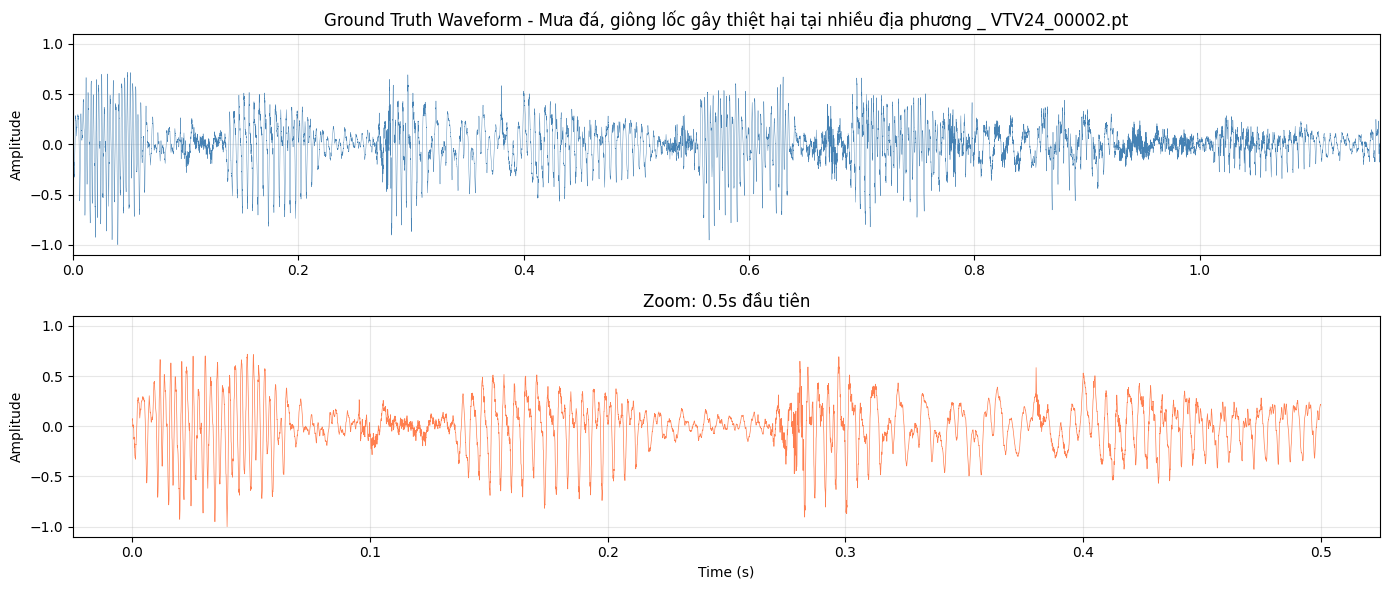

In [54]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# Đường dẫn tới thư mục chứa file .pt
data_dir = "Processed_Data"
file_list = [f for f in os.listdir(data_dir) if f.endswith('.pt')]
print(f"Có {len(file_list)} file")

# Lấy file đầu tiên
sample_file = os.path.join(data_dir, file_list[0])
data = torch.load(sample_file, weights_only=False)
audio_gt = data['audio']  # (T, 640)

# Flatten thành waveform 1D
waveform = audio_gt.numpy().flatten()
time_axis = np.arange(len(waveform)) / 16000.0

print(f"Shape: {audio_gt.shape}")
print(f"Min: {waveform.min():.4f}, Max: {waveform.max():.4f}, Mean: {waveform.mean():.4f}")
print(f"Duration: {time_axis[-1]:.2f}s")

# Plot waveform
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Full waveform
axes[0].plot(time_axis, waveform, linewidth=0.3, color='steelblue')
axes[0].set_title(f"Ground Truth Waveform - {file_list[0]}")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(0, time_axis[-1])
axes[0].set_ylim(-1.1, 1.1)
axes[0].grid(True, alpha=0.3)

# Zoom vào 0.5s đầu
zoom_samples = min(8000, len(waveform))  # 0.5s
axes[1].plot(time_axis[:zoom_samples], waveform[:zoom_samples], linewidth=0.5, color='coral')
axes[1].set_title("Zoom: 0.5s đầu tiên")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Predict vs ground truth

In [ ]:
from spikingjelly.activation_based import functional

encoder.eval()
decoder.eval()
with torch.no_grad():
    v, a, l = next(iter(dataloader))
    v = v.to(device)
    functional.reset_net(encoder)
    audio_pred = decoder(encoder(v))
    
    T_real = l[0].item()
    pred_wave = audio_pred[0, :T_real, :].cpu().numpy().flatten()
    gt_wave = a[0, :T_real, :].cpu().numpy().flatten()

# Vẽ waveform
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

time_axis = np.arange(len(gt_wave)) / 16000.0

axes[0].plot(time_axis, gt_wave, linewidth=0.5, color='steelblue')
axes[0].set_title("Ground Truth Waveform")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(0, time_axis[-1])
axes[0].set_ylim(-1.1, 1.1)

axes[1].plot(time_axis, pred_wave, linewidth=0.5, color='coral')
axes[1].set_title("Predicted Waveform")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlim(0, time_axis[-1])
axes[1].set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

# Print stats
print(f"GT:   min={gt_wave.min():.4f}, max={gt_wave.max():.4f}, mean={gt_wave.mean():.4f}")
print(f"Pred: min={pred_wave.min():.4f}, max={pred_wave.max():.4f}, mean={pred_wave.mean():.4f}")


# New approach: TFiLM WIRE DECODER

## FiLM + WIRE

In [ ]:
class FiLMWIRE(nn.Module):
    def __init__(self, in_features, out_features, omega_zero=30.0, scale=1.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.omega_zero = omega_zero
        self.scale = scale
        self.is_first = is_first
        with torch.no_grad():
            if self.is_first:
                bound = 1 / in_features
            else:
                bound = torch.sqrt(torch.tensor(6.0 / in_features)) / self.omega_zero
            self.linear.weight.uniform_(-bound, bound)

    def forward(self, X, gamma, beta):
        X = self.linear(X)
        if not self.is_first:
            X = self.omega_zero * X 
        modulated = gamma * X + beta
        real = torch.cos(self.omega_zero * modulated) * torch.exp(-modulated**2 / (2 * self.scale**2))
        return real


## FiLM WIRE DECODER

In [ ]:
class TFiLMWIREDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=640, num_layers=4, omega_zero=30.0, scale=5.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = num_layers * 2 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.kaiming_uniform_(self.param_net.weight)
            self.param_net.weight.data *= 0.01
            with torch.no_grad():
                self.param_net.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
        else:
            self.param_gru = nn.GRU(
                condition_dim, condition_dim,
                batch_first=True, bidirectional=True
            )
            self.param_proj = nn.Linear(condition_dim * 2, total_params)
            # Init: Kaiming * 0.01 theo SIREN paper
            nn.init.kaiming_uniform_(self.param_proj.weight)
            self.param_proj.weight.data *= 0.01
            self.param_proj.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
            #     nn.Linear(condition_dim, condition_dim),
            #     nn.ReLU(),
            #     nn.Linear(condition_dim, total_params)
            # )

        self.wire_layers = nn.ModuleList()
        self.wire_layers.append(FiLMWIRE(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, scale=scale, is_first=True))
        for _ in range(1, num_layers):
            self.wire_layers.append(FiLMWIRE(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, scale=scale, is_first=False))
        self.final_layer = nn.Linear(hidden_dim , out_dim)
        self.output_scale = nn.Parameter(torch.ones(1))  # learnable scale
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)

        # Time positional encoding
        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
    
    def forward(self, Condition):
        B, T, _ = Condition.shape
        if hasattr(self, 'param_net') and isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            gru_out, _ = self.param_gru(Condition)  # (B, T, condition_dim*2)
            params = self.param_proj(gru_out.reshape(B * T, -1))  # (B*T, total_params)
            params = params.reshape(B, T, -1)
        
        gammas = []
        betas = []

        for i in range(self.num_layers):
            start = i * 2 * self.hidden_dim
            beta = params[:, :, start: start + self.hidden_dim]
            gamma = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]
            gammas.append(gamma)
            betas.append(beta)
        
        # Time positional encoding: mỗi frame nhận input khác nhau
        X_base = self.input_constant.expand(B * T, -1)
        # Tạo sinusoidal time positions
        t_pos = torch.linspace(0, 1, T, device=Condition.device)  # [0, 1]
        t_pos = t_pos.unsqueeze(0).expand(B, -1).reshape(B * T, 1)  # (B*T, 1)
        # Sinusoidal encoding: [sin(2^0 * pi * t), cos(2^0 * pi * t), ...]
        # Bounded sinusoidal frequencies. The previous 2**arange(hidden_dim//2)
        # overflowed for hidden_dim=256 and produced sin(inf)=nan.
        half_dim = self.hidden_dim // 2
        pe_dtype = torch.float32
        freqs = torch.linspace(1.0, 32.0, half_dim, device=Condition.device, dtype=pe_dtype)
        angles = t_pos.to(dtype=pe_dtype) * freqs.unsqueeze(0) * torch.pi
        pe = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # (B*T, hidden_dim)
        if pe.shape[-1] < self.hidden_dim:
            pe = torch.nn.functional.pad(pe, (0, self.hidden_dim - pe.shape[-1]))
        pe = pe.to(dtype=Condition.dtype)
        time_signal = self.time_embed(pe)  # (B*T, hidden_dim)
        X = X_base + time_signal  # Mỗi frame có input khác nhau
        gammas_flat = [g.reshape(B * T, -1) for g in gammas]
        betas_flat = [b.reshape(B * T, -1) for b in betas]

        for i, layer in enumerate(self.wire_layers):
            X = layer(X, gammas_flat[i], betas_flat[i])
        out = self.final_layer(X)
        out = torch.tanh(out) * self.output_scale  # [-scale, +scale], waveform range
        out = out.reshape(B, T, -1)
        return out


# New approach: WIRE + SIREN DUAL DECODER

## Dual Layer

In [ ]:
class DualFiLMLayer(nn.Module):
    def __init__(self, in_features, out_features, omega_siren=30.0, omega_wire=30.0, scale=5.0, is_first=False):
        super().__init__()
        self.siren = FiLMSIREN(in_features, out_features, omega_siren, is_first)
        self.wire = FiLMWIRE(in_features, out_features, omega_wire, scale, is_first)
        self.fusion = nn.Sequential(
            nn.Linear(out_features * 2, out_features),
            nn.ReLU(),
            nn.Linear(out_features, out_features)
        )

    def forward(self, X, gamma_s, beta_s, gamma_w, beta_w):
        out_siren = self.siren(X, gamma_s, beta_s)
        out_wire = self.wire(X, gamma_w, beta_w)
        out = torch.cat([out_siren, out_wire], dim=-1)
        out = self.fusion(out)
        return out


## Dual Decoder

In [ ]:
class DualDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=640, num_layers=4, omega_siren=30.0, omega_wire=30.0, scale=5.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = self.num_layers * 4 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.kaiming_uniform_(self.param_net.weight)
            self.param_net.weight.data *= 0.01
            with torch.no_grad():
                self.param_net.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)

        else: 
            self.param_gru = nn.GRU(
                condition_dim, condition_dim,
                batch_first=True, bidirectional=True
            )
            self.param_proj = nn.Linear(condition_dim * 2, total_params)
            # Init: Kaiming * 0.01 theo SIREN paper
            nn.init.kaiming_uniform_(self.param_proj.weight)
            self.param_proj.weight.data *= 0.01
            self.param_proj.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
            #     nn.Linear(condition_dim, condition_dim),
            #     nn.ReLU(),
            #     nn.Linear(condition_dim, total_params)
            # )

        self.dual_layers = nn.ModuleList()
        self.dual_layers.append(DualFiLMLayer(hidden_dim, hidden_dim, omega_siren, omega_wire, scale, is_first=True))
        for _ in range(1, num_layers):
            self.dual_layers.append(DualFiLMLayer(hidden_dim, hidden_dim, omega_siren, omega_wire, scale, is_first=False))
        self.final_layer = nn.Linear(hidden_dim, out_dim)
        self.output_scale = nn.Parameter(torch.ones(1))  # learnable scale
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)

        # Time positional encoding
        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, Condition):
        B, T, _ = Condition.shape
        if hasattr(self, 'param_net') and isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            gru_out, _ = self.param_gru(Condition)  # (B, T, condition_dim*2)
            params = self.param_proj(gru_out.reshape(B * T, -1))  # (B*T, total_params)
            params = params.reshape(B, T, -1)

        gammas_s = []
        betas_s = []
        gammas_w = []
        betas_w = []

        for i in range(self.num_layers):
            start = i * 4 * self.hidden_dim
            # SIREN
            beta_s = params[:, :, start: start + self.hidden_dim]
            gamma_s = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]

            # WIRE
            beta_w = params[:, :, start + 2 * self.hidden_dim: start + 3 * self.hidden_dim]
            gamma_w = params[:, :, start + 3 * self.hidden_dim: start + 4 * self.hidden_dim]

            gammas_s.append(gamma_s)
            betas_s.append(beta_s)
            gammas_w.append(gamma_w)
            betas_w.append(beta_w)

        # Time positional encoding: mỗi frame nhận input khác nhau
        X_base = self.input_constant.expand(B * T, -1)
        # Tạo sinusoidal time positions
        t_pos = torch.linspace(0, 1, T, device=Condition.device)  # [0, 1]
        t_pos = t_pos.unsqueeze(0).expand(B, -1).reshape(B * T, 1)  # (B*T, 1)
        # Sinusoidal encoding: [sin(2^0 * pi * t), cos(2^0 * pi * t), ...]
        # Bounded sinusoidal frequencies. The previous 2**arange(hidden_dim//2)
        # overflowed for hidden_dim=256 and produced sin(inf)=nan.
        half_dim = self.hidden_dim // 2
        pe_dtype = torch.float32
        freqs = torch.linspace(1.0, 32.0, half_dim, device=Condition.device, dtype=pe_dtype)
        angles = t_pos.to(dtype=pe_dtype) * freqs.unsqueeze(0) * torch.pi
        pe = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # (B*T, hidden_dim)
        if pe.shape[-1] < self.hidden_dim:
            pe = torch.nn.functional.pad(pe, (0, self.hidden_dim - pe.shape[-1]))
        pe = pe.to(dtype=Condition.dtype)
        time_signal = self.time_embed(pe)  # (B*T, hidden_dim)
        X = X_base + time_signal  # Mỗi frame có input khác nhau
        
        gammas_s_flat = [g.reshape(B * T, -1) for g in gammas_s]
        betas_s_flat = [b.reshape(B * T, -1) for b in betas_s]
        gammas_w_flat = [g.reshape(B * T, -1) for g in gammas_w]
        betas_w_flat = [b.reshape(B * T, -1) for b in betas_w]

        for i, layer in enumerate(self.dual_layers):
            X = layer(
                X,
                gammas_s_flat[i], betas_s_flat[i],
                gammas_w_flat[i], betas_w_flat[i]
            )
        out = self.final_layer(X)
        out = torch.tanh(out) * self.output_scale  # [-scale, +scale], waveform range
        out = out.reshape(B, T, -1)
        return out
            


# New approach: TFiLM FINER DECODER

## TFiLM FINER Layer

In [ ]:
class FiLMFINER(nn.Module):
    def __init__(self, in_features, out_features, omega_zero=30.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.omega_zero = omega_zero
        self.is_first = is_first
        with torch.no_grad():
            if self.is_first:
                bound = 1 / in_features
            else:
                bound = torch.sqrt(torch.tensor(6.0 / in_features)) / self.omega_zero
            self.linear.weight.uniform_(-bound, bound)
        
    def forward(self, X, gamma, beta):
        out_dtype = X.dtype
        X = self.linear(X)
        if not self.is_first:
            X = self.omega_zero * X
        modulated = gamma.float() * X.float() + beta.float()
        phase = self.omega_zero * (torch.abs(modulated) + 1.0) * modulated
        phase = torch.nan_to_num(phase, nan=0.0, posinf=1000.0, neginf=-1000.0).clamp(-1000.0, 1000.0)
        return torch.sin(phase).to(dtype=out_dtype)


## TFiLM FINER DECODER

In [ ]:
class TFiLMFINERDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=640, num_layers=4, omega_zero=30.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = num_layers * 2 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.kaiming_uniform_(self.param_net.weight)
            self.param_net.weight.data *= 0.01
            with torch.no_grad():
                self.param_net.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
        else:
            self.param_gru = nn.GRU(
                condition_dim, condition_dim,
                batch_first=True, bidirectional=True
            )
            self.param_proj = nn.Linear(condition_dim * 2, total_params)
            # Init: Kaiming * 0.01 theo SIREN paper
            nn.init.kaiming_uniform_(self.param_proj.weight)
            self.param_proj.weight.data *= 0.01
            self.param_proj.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
            #     nn.Linear(condition_dim, condition_dim),
            #     nn.ReLU(),
            #     nn.Linear(condition_dim, total_params)
            # )

        self.finer_layers = nn.ModuleList()
        self.finer_layers.append(FiLMFINER(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=True))
        for _ in range(1, num_layers):
            self.finer_layers.append(FiLMFINER(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=False))
        self.final_layer = nn.Linear(hidden_dim , out_dim)
        self.output_scale = nn.Parameter(torch.ones(1))  # learnable scale
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)

        # Time positional encoding
        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
    
    def forward(self, Condition):
        B, T, _ = Condition.shape
        if hasattr(self, 'param_net') and isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            gru_out, _ = self.param_gru(Condition)  # (B, T, condition_dim*2)
            params = self.param_proj(gru_out.reshape(B * T, -1))  # (B*T, total_params)
            params = params.reshape(B, T, -1)
        
        gammas = []
        betas = []

        for i in range(self.num_layers):
            start = i * 2 * self.hidden_dim
            beta = params[:, :, start: start + self.hidden_dim]
            gamma = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]
            gammas.append(gamma)
            betas.append(beta)
        
        # Time positional encoding: mỗi frame nhận input khác nhau
        X_base = self.input_constant.expand(B * T, -1)
        # Tạo sinusoidal time positions
        t_pos = torch.linspace(0, 1, T, device=Condition.device)  # [0, 1]
        t_pos = t_pos.unsqueeze(0).expand(B, -1).reshape(B * T, 1)  # (B*T, 1)
        # Sinusoidal encoding: [sin(2^0 * pi * t), cos(2^0 * pi * t), ...]
        # Bounded sinusoidal frequencies. The previous 2**arange(hidden_dim//2)
        # overflowed for hidden_dim=256 and produced sin(inf)=nan.
        half_dim = self.hidden_dim // 2
        pe_dtype = torch.float32
        freqs = torch.linspace(1.0, 32.0, half_dim, device=Condition.device, dtype=pe_dtype)
        angles = t_pos.to(dtype=pe_dtype) * freqs.unsqueeze(0) * torch.pi
        pe = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # (B*T, hidden_dim)
        if pe.shape[-1] < self.hidden_dim:
            pe = torch.nn.functional.pad(pe, (0, self.hidden_dim - pe.shape[-1]))
        pe = pe.to(dtype=Condition.dtype)
        time_signal = self.time_embed(pe)  # (B*T, hidden_dim)
        X = X_base + time_signal  # Mỗi frame có input khác nhau
        gammas_flat = [g.reshape(B * T, -1) for g in gammas]
        betas_flat = [b.reshape(B * T, -1) for b in betas]

        for i, layer in enumerate(self.finer_layers):
            X = layer(X, gammas_flat[i], betas_flat[i])
        out = self.final_layer(X)
        out = torch.tanh(out) * self.output_scale  # [-scale, +scale], waveform range
        out = out.reshape(B, T, -1)
        return out


# New approach: Wrap FINER SIREN DECODER

## FINER SIREN WRAP

In [ ]:
# out = sin((∣b~∣+1)⋅(ω0(Wx+b)))
class FiLMWrapFINSIREN(nn.Module):
    def __init__(self, in_features, out_features, omega_zero=30.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=True)
        self.omega_zero = omega_zero
        self.is_first = is_first
        self.freq_bias = nn.Parameter(torch.empty(out_features))
        self.reset_parameters()
    
    def reset_parameters(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1.0 / self.linear.in_features
            else:
                bound = torch.sqrt(torch.tensor(6.0 / self.linear.in_features)) / self.omega_zero
            self.linear.weight.uniform_(-bound, bound)
            nn.init.zeros_(self.linear.bias)
            nn.init.uniform_(self.freq_bias, -10.0, 10.0)
    
    def forward(self, X, gamma, beta):
        X = self.linear(X)
        if not self.is_first:
            X = self.omega_zero * X
        modulated = gamma * X + beta
        scaled = torch.abs(self.freq_bias) + 1.0
        out = torch.sin(scaled.unsqueeze(0) * modulated)
        return out

## TFiLM WRAP FIN SIN

In [ ]:
class TFiLMWrapFISINDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=640, num_layers=4, omega_zero=30.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = num_layers * 2 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.kaiming_uniform_(self.param_net.weight)
            self.param_net.weight.data *= 0.01
            with torch.no_grad():
                self.param_net.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
        else:
            self.param_gru = nn.GRU(
                condition_dim, condition_dim,
                batch_first=True, bidirectional=True
            )
            self.param_proj = nn.Linear(condition_dim * 2, total_params)
            # Init: Kaiming * 0.01 theo SIREN paper
            nn.init.kaiming_uniform_(self.param_proj.weight)
            self.param_proj.weight.data *= 0.01
            self.param_proj.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
            #     nn.Linear(condition_dim, condition_dim),
            #     nn.ReLU(),
            #     nn.Linear(condition_dim, total_params)
            # )

        self.wrap_layers = nn.ModuleList()
        self.wrap_layers.append(FiLMWrapFINSIREN(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=True))
        for _ in range(1, num_layers):
            self.wrap_layers.append(FiLMWrapFINSIREN(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, is_first=False))
        self.final_layer = nn.Linear(hidden_dim , out_dim)
        self.output_scale = nn.Parameter(torch.ones(1))  # learnable scale
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)

        # Time positional encoding
        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
    
    def forward(self, Condition):
        B, T, _ = Condition.shape
        if hasattr(self, 'param_net') and isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            gru_out, _ = self.param_gru(Condition)  # (B, T, condition_dim*2)
            params = self.param_proj(gru_out.reshape(B * T, -1))  # (B*T, total_params)
            params = params.reshape(B, T, -1)
        
        gammas = []
        betas = []

        for i in range(self.num_layers):
            start = i * 2 * self.hidden_dim
            beta = params[:, :, start: start + self.hidden_dim]
            gamma = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]
            gammas.append(gamma)
            betas.append(beta)
        
        # Time positional encoding: mỗi frame nhận input khác nhau
        X_base = self.input_constant.expand(B * T, -1)
        # Tạo sinusoidal time positions
        t_pos = torch.linspace(0, 1, T, device=Condition.device)  # [0, 1]
        t_pos = t_pos.unsqueeze(0).expand(B, -1).reshape(B * T, 1)  # (B*T, 1)
        # Sinusoidal encoding: [sin(2^0 * pi * t), cos(2^0 * pi * t), ...]
        # Bounded sinusoidal frequencies. The previous 2**arange(hidden_dim//2)
        # overflowed for hidden_dim=256 and produced sin(inf)=nan.
        half_dim = self.hidden_dim // 2
        pe_dtype = torch.float32
        freqs = torch.linspace(1.0, 32.0, half_dim, device=Condition.device, dtype=pe_dtype)
        angles = t_pos.to(dtype=pe_dtype) * freqs.unsqueeze(0) * torch.pi
        pe = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # (B*T, hidden_dim)
        if pe.shape[-1] < self.hidden_dim:
            pe = torch.nn.functional.pad(pe, (0, self.hidden_dim - pe.shape[-1]))
        pe = pe.to(dtype=Condition.dtype)
        time_signal = self.time_embed(pe)  # (B*T, hidden_dim)
        X = X_base + time_signal  # Mỗi frame có input khác nhau
        gammas_flat = [g.reshape(B * T, -1) for g in gammas]
        betas_flat = [b.reshape(B * T, -1) for b in betas]

        for i, layer in enumerate(self.wrap_layers):
            X = layer(X, gammas_flat[i], betas_flat[i])
        out = self.final_layer(X)
        out = torch.tanh(out) * self.output_scale  # [-scale, +scale], waveform range
        out = out.reshape(B, T, -1)
        return out


# New approach: Wrap FINER WIRE DECODER

## FINER WIRE WRAP

In [ ]:
class FiLMWrapFINWIRE(nn.Module):
    def __init__(self, in_features, out_features, omega_zero=30.0, scale=5.0, is_first=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.omega_zero = omega_zero
        self.scale = scale
        self.is_first = is_first
        self.freq_bias = nn.Parameter(torch.empty(out_features))
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.linear.in_features
            else:
                bound = torch.sqrt(torch.tensor(6.0 / in_features)) / self.omega_zero
            self.linear.weight.uniform_(-bound, bound)
            nn.init.zeros_(self.linear.bias)
            nn.init.uniform_(self.freq_bias, -10, 10)

    def forward(self, X, gamma, beta):
        X = self.linear(X)
        if not self.is_first:
            X = self.omega_zero * X 
        modulated = gamma * X + beta
        scaled = torch.abs(self.freq_bias) + 1.0
        real = torch.cos(scaled.unsqueeze(0) * modulated) * torch.exp(-modulated**2 / (2 * self.scale**2))
        return real


## TFiLM WRAP FIN WI DEOCDER

In [ ]:
class TFiLMWrapFIWIDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=640, num_layers=4, omega_zero=30.0, scale=5.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = num_layers * 2 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.kaiming_uniform_(self.param_net.weight)
            self.param_net.weight.data *= 0.01
            with torch.no_grad():
                self.param_net.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
        else:
            self.param_gru = nn.GRU(
                condition_dim, condition_dim,
                batch_first=True, bidirectional=True
            )
            self.param_proj = nn.Linear(condition_dim * 2, total_params)
            # Init: Kaiming * 0.01 theo SIREN paper
            nn.init.kaiming_uniform_(self.param_proj.weight)
            self.param_proj.weight.data *= 0.01
            self.param_proj.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
            #     nn.Linear(condition_dim, condition_dim),
            #     nn.ReLU(),
            #     nn.Linear(condition_dim, total_params)
            # )

        self.wrap_layers = nn.ModuleList()
        self.wrap_layers.append(FiLMWrapFINWIRE(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, scale=scale, is_first=True))
        for _ in range(1, num_layers):
            self.wrap_layers.append(FiLMWrapFINWIRE(in_features=hidden_dim, out_features=hidden_dim, omega_zero=omega_zero, scale=scale, is_first=False))
        self.final_layer = nn.Linear(hidden_dim , out_dim)
        self.output_scale = nn.Parameter(torch.ones(1))  # learnable scale
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)

        # Time positional encoding
        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
    
    def forward(self, Condition):
        B, T, _ = Condition.shape
        if hasattr(self, 'param_net') and isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            gru_out, _ = self.param_gru(Condition)  # (B, T, condition_dim*2)
            params = self.param_proj(gru_out.reshape(B * T, -1))  # (B*T, total_params)
            params = params.reshape(B, T, -1)
        
        gammas = []
        betas = []

        for i in range(self.num_layers):
            start = i * 2 * self.hidden_dim
            beta = params[:, :, start: start + self.hidden_dim]
            gamma = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]
            gammas.append(gamma)
            betas.append(beta)
        
        # Time positional encoding: mỗi frame nhận input khác nhau
        X_base = self.input_constant.expand(B * T, -1)
        # Tạo sinusoidal time positions
        t_pos = torch.linspace(0, 1, T, device=Condition.device)  # [0, 1]
        t_pos = t_pos.unsqueeze(0).expand(B, -1).reshape(B * T, 1)  # (B*T, 1)
        # Sinusoidal encoding: [sin(2^0 * pi * t), cos(2^0 * pi * t), ...]
        # Bounded sinusoidal frequencies. The previous 2**arange(hidden_dim//2)
        # overflowed for hidden_dim=256 and produced sin(inf)=nan.
        half_dim = self.hidden_dim // 2
        pe_dtype = torch.float32
        freqs = torch.linspace(1.0, 32.0, half_dim, device=Condition.device, dtype=pe_dtype)
        angles = t_pos.to(dtype=pe_dtype) * freqs.unsqueeze(0) * torch.pi
        pe = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # (B*T, hidden_dim)
        if pe.shape[-1] < self.hidden_dim:
            pe = torch.nn.functional.pad(pe, (0, self.hidden_dim - pe.shape[-1]))
        pe = pe.to(dtype=Condition.dtype)
        time_signal = self.time_embed(pe)  # (B*T, hidden_dim)
        X = X_base + time_signal  # Mỗi frame có input khác nhau
        gammas_flat = [g.reshape(B * T, -1) for g in gammas]
        betas_flat = [b.reshape(B * T, -1) for b in betas]

        for i, layer in enumerate(self.wrap_layers):
            X = layer(X, gammas_flat[i], betas_flat[i])
        out = self.final_layer(X)
        out = torch.tanh(out) * self.output_scale  # [-scale, +scale], waveform range
        out = out.reshape(B, T, -1)
        return out


# New approach: Dual Wrap FINER - SIREN WIRE

## Dual Wrap Layer

In [ ]:
class DualWrapLayer(nn.Module):
    def __init__(self, in_features, out_features, omega_fisin=30.0, omega_fiwi=30.0, scale=5.0, is_first=False):
        super().__init__()
        self.fisin = FiLMWrapFINSIREN(in_features, out_features, omega_fisin, is_first)
        self.fiwi = FiLMWrapFINWIRE(in_features, out_features, omega_fiwi, scale, is_first)
        self.fusion = nn.Sequential(
            nn.Linear(out_features * 2, out_features),
            nn.ReLU(),
            nn.Linear(out_features, out_features)
        )
    
    def forward(self, X, gamma_fs, beta_fs, gamma_fw, beta_fw):
        out_fs = self.fisin(X, gamma_fs, beta_fs)
        out_fw = self.fiwi(X, gamma_fw, beta_fw)
        out = torch.cat([out_fs, out_fw], dim=-1)
        out = self.fusion(out)
        return out

## Dual Wrap Decoder

In [ ]:
class DualWrapDecoder(nn.Module):
    def __init__(self, condition_dim=512, hidden_dim=256, out_dim=640, num_layers=4, omega_siren=30.0, omega_wire=30.0, scale=5.0, use_conv=False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        total_params = self.num_layers * 4 * hidden_dim
        if use_conv:
            self.param_net = nn.Conv1d(condition_dim, total_params, kernel_size=3, padding=1)
            nn.init.kaiming_uniform_(self.param_net.weight)
            self.param_net.weight.data *= 0.01
            with torch.no_grad():
                self.param_net.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)

        else: 
            self.param_gru = nn.GRU(
                condition_dim, condition_dim,
                batch_first=True, bidirectional=True
            )
            self.param_proj = nn.Linear(condition_dim * 2, total_params)
            # Init: Kaiming * 0.01 theo SIREN paper
            nn.init.kaiming_uniform_(self.param_proj.weight)
            self.param_proj.weight.data *= 0.01
            self.param_proj.bias.data.uniform_(-1.0 / hidden_dim, 1.0 / hidden_dim)
            #     nn.Linear(condition_dim, condition_dim),
            #     nn.ReLU(),
            #     nn.Linear(condition_dim, total_params)
            # )

        self.dual_layers = nn.ModuleList()
        self.dual_layers.append(DualWrapLayer(hidden_dim, hidden_dim, omega_siren, omega_wire, scale, is_first=True))
        for _ in range(1, num_layers):
            self.dual_layers.append(DualWrapLayer(hidden_dim, hidden_dim, omega_siren, omega_wire, scale, is_first=False))
        self.final_layer = nn.Linear(hidden_dim, out_dim)
        self.output_scale = nn.Parameter(torch.ones(1))  # learnable scale
        nn.init.xavier_uniform_(self.final_layer.weight)
        nn.init.zeros_(self.final_layer.bias)

        self.input_constant = nn.Parameter(torch.randn(1, hidden_dim) * 0.1)

        # Time positional encoding
        self.time_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, Condition):
        B, T, _ = Condition.shape
        if hasattr(self, 'param_net') and isinstance(self.param_net, nn.Conv1d):
            params = self.param_net(Condition.permute(0, 2, 1))
            params = params.permute(0, 2, 1)
        else:
            gru_out, _ = self.param_gru(Condition)  # (B, T, condition_dim*2)
            params = self.param_proj(gru_out.reshape(B * T, -1))  # (B*T, total_params)
            params = params.reshape(B, T, -1)

        gammas_s = []
        betas_s = []
        gammas_w = []
        betas_w = []

        for i in range(self.num_layers):
            start = i * 4 * self.hidden_dim
            # SIREN
            beta_s = params[:, :, start: start + self.hidden_dim]
            gamma_s = params[:, :, start + self.hidden_dim: start + 2 * self.hidden_dim]

            # WIRE
            beta_w = params[:, :, start + 2 * self.hidden_dim: start + 3 * self.hidden_dim]
            gamma_w = params[:, :, start + 3 * self.hidden_dim: start + 4 * self.hidden_dim]

            gammas_s.append(gamma_s)
            betas_s.append(beta_s)
            gammas_w.append(gamma_w)
            betas_w.append(beta_w)

        # Time positional encoding: mỗi frame nhận input khác nhau
        X_base = self.input_constant.expand(B * T, -1)
        # Tạo sinusoidal time positions
        t_pos = torch.linspace(0, 1, T, device=Condition.device)  # [0, 1]
        t_pos = t_pos.unsqueeze(0).expand(B, -1).reshape(B * T, 1)  # (B*T, 1)
        # Sinusoidal encoding: [sin(2^0 * pi * t), cos(2^0 * pi * t), ...]
        # Bounded sinusoidal frequencies. The previous 2**arange(hidden_dim//2)
        # overflowed for hidden_dim=256 and produced sin(inf)=nan.
        half_dim = self.hidden_dim // 2
        pe_dtype = torch.float32
        freqs = torch.linspace(1.0, 32.0, half_dim, device=Condition.device, dtype=pe_dtype)
        angles = t_pos.to(dtype=pe_dtype) * freqs.unsqueeze(0) * torch.pi
        pe = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # (B*T, hidden_dim)
        if pe.shape[-1] < self.hidden_dim:
            pe = torch.nn.functional.pad(pe, (0, self.hidden_dim - pe.shape[-1]))
        pe = pe.to(dtype=Condition.dtype)
        time_signal = self.time_embed(pe)  # (B*T, hidden_dim)
        X = X_base + time_signal  # Mỗi frame có input khác nhau
        gammas_s_flat = [g.reshape(B * T, -1) for g in gammas_s]
        betas_s_flat = [b.reshape(B * T, -1) for b in betas_s]
        gammas_w_flat = [g.reshape(B * T, -1) for g in gammas_w]
        betas_w_flat = [b.reshape(B * T, -1) for b in betas_w]

        for i, layer in enumerate(self.dual_layers):
            X = layer(
                X,
                gammas_s_flat[i], betas_s_flat[i],
                gammas_w_flat[i], betas_w_flat[i]
            )
        out = self.final_layer(X)
        out = torch.tanh(out) * self.output_scale  # [-scale, +scale], waveform range
        out = out.reshape(B, T, -1)
        return out
            


## 300ep


In [ ]:

# ===== OVERFIT TEST: Train tr?n 1 file .pt duy nh?t =====
# D?ng chung cho c? SNN v? Non-SNN encoder.

import torch
import torch.nn as nn
import os
import torchaudio
import gc
from spikingjelly.activation_based import functional

def train_single_sample(encoder, decoder, pt_path, device,
                        num_epochs=300, lr=1e-4, max_frames=30,
                        loss_type="mse", lambda_stft=0.05):
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

    data = torch.load(pt_path, map_location='cpu', weights_only=False)
    video = data['video'].float()
    audio = data['audio'].float()
    if video.dim() == 3:
        video = video.unsqueeze(0)
    video = video.unsqueeze(0).to(device)   # (1, 1, T, 112, 112)
    audio = audio.unsqueeze(0).to(device)   # (1, T, 640)

    T = min(video.shape[2], audio.shape[1])
    video = video[:, :, :T]
    audio = audio[:, :T]
    if T > max_frames:
        print(f"T={T} qu? d?i cho overfit test, c?t xu?ng {max_frames} frames...")
        video = video[:, :, :max_frames]
        audio = audio[:, :max_frames]
        T = max_frames

    print(f"Video shape: {video.shape}")
    print(f"Audio shape: {audio.shape}")
    print(f"Training {num_epochs} epochs on: {os.path.basename(pt_path)}")
    print(f"Loss: {loss_type} | max_frames={max_frames}")
    print("-" * 60)

    optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr)
    if loss_type == "combined":
        criterion_local = CombinedAudioLoss(lambda_mse=1.0, lambda_stft=lambda_stft).to(device)
    else:
        criterion_local = nn.MSELoss()
    amp_enabled = device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    encoder.train()
    decoder.train()
    history = []

    for epoch in range(1, num_epochs + 1):
        functional.reset_net(encoder)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=amp_enabled):
            z = encoder(video)
            audio_pred = decoder(z)

        # Loss stays in FP32 to avoid NaN from STFT/log-magnitude under AMP.
        with torch.amp.autocast('cuda', enabled=False):
            if loss_type == "combined":
                lengths = torch.tensor([T], device=device)
                loss = criterion_local(audio_pred.float(), audio.float(), lengths)
            else:
                loss = criterion_local(audio_pred.float(), audio.float())
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite overfit loss at epoch={epoch}: {float(loss.detach().cpu())}")

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 1.0)
        scaler.step(optimizer)
        scaler.update()

        history.append(float(loss.detach().cpu()))
        if epoch == 1 or epoch % 20 == 0 or epoch == num_epochs:
            with torch.no_grad():
                pred_min = audio_pred.min().item()
                pred_max = audio_pred.max().item()
                pred_mean = audio_pred.mean().item()
            print(f"Epoch {epoch:3d}/{num_epochs} | Loss: {history[-1]:.6f} | "
                  f"Pred min/max/mean: {pred_min:.4f}/{pred_max:.4f}/{pred_mean:.4f}")

        del z, audio_pred, loss
        functional.reset_net(encoder)
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        functional.reset_net(encoder)
        with torch.amp.autocast('cuda', enabled=amp_enabled):
            audio_pred = decoder(encoder(video))
        waveform_pred = audio_pred[0].reshape(1, -1).cpu().float()
        waveform_pred = waveform_pred / (waveform_pred.abs().max() + 1e-8)
        torchaudio.save(f'overfit_pred_{ENCODER_TYPE}.wav', waveform_pred, 16000)
        waveform_gt = audio[0].reshape(1, -1).cpu().float()
        torchaudio.save(f'overfit_gt_{ENCODER_TYPE}.wav', waveform_gt, 16000)

    print("-" * 60)
    print(f"Final Loss: {history[-1]:.6f}")
    print(f"Saved: overfit_pred_{ENCODER_TYPE}.wav, overfit_gt_{ENCODER_TYPE}.wav")

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.plot(history, linewidth=0.8)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Overfit Single Sample - {ENCODER_TYPE}')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return history

# ===== CH?Y =====
pt_path = os.path.join("Processed_Data", sorted([f for f in os.listdir("Processed_Data") if f.endswith(".pt")])[0])
encoder = build_encoder(globals().get("ENCODER_TYPE", "non_snn")).to(device)
decoder = TFiLMSIRENDecoder(out_dim=640).to(device)
history = train_single_sample(
    encoder, decoder, pt_path, device,
    num_epochs=300,
    max_frames=30,
    loss_type="mse",
    lambda_stft=0.05,
)


In [ ]:
del encoder

import gc; gc.collect()
import torch; torch.cuda.empty_cache()

In [ ]:
import torch
from spikingjelly.activation_based import functional

def plot_waveform_from_pt(pt_path, encoder, decoder, device):
    data = torch.load(pt_path, weights_only=False)
    video = data['video']  # (1, T, 112, 112) hoặc (T, 112, 112) cần unsqueeze
    audio_gt = data['audio']  # (T, 640) - waveform frame-wise

    # Đảm bảo video shape (1, 1, T, 112, 112)
    if video.dim() == 4:  # (1, T, 112, 112)
        video = video.unsqueeze(0)  # (1, 1, T, 112, 112)
    elif video.dim() == 3:  # (T, 112, 112)
        video = video.unsqueeze(0).unsqueeze(1)  # (1, 1, T, 112, 112)
    # else đã đúng

    video = video.to(device)
    audio_gt = audio_gt  # (T, 640)

    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        functional.reset_net(encoder)
        audio_pred = decoder(encoder(video))  # (1, T, 640)
    pred_wave = audio_pred[0, :, :].cpu().numpy().flatten()
    gt_wave = audio_gt.cpu().numpy().flatten()

    # Vẽ
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    time_axis = np.arange(len(gt_wave)) / 16000.0
    axes[0].plot(time_axis, gt_wave, linewidth=0.5, color='steelblue')
    axes[0].set_title("Ground Truth Waveform")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_xlim(0, time_axis[-1])
    axes[0].set_ylim(-1.1, 1.1)
    axes[1].plot(time_axis, pred_wave, linewidth=0.5, color='coral')
    axes[1].set_title("Predicted Waveform")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Amplitude")
    axes[1].set_xlim(0, time_axis[-1])
    axes[1].set_ylim(-1.1, 1.1)
    plt.tight_layout()
    plt.show()
    print(f"GT:   min={gt_wave.min():.4f}, max={gt_wave.max():.4f}, mean={gt_wave.mean():.4f}")
    print(f"Pred: min={pred_wave.min():.4f}, max={pred_wave.max():.4f}, mean={pred_wave.mean():.4f}")

In [ ]:

# Ch?y sau khi ?? c? encoder/decoder ?? train ho?c ?? load checkpoint.
sample_pt = os.path.join("Processed_Data", sorted([f for f in os.listdir("Processed_Data") if f.endswith(".pt")])[0])
plot_waveform_from_pt(sample_pt, encoder, decoder, device)


In [ ]:
# ===== KIỂM TRA ẢNH MÔI ĐÃ CẮT TỪ FILE .PT =====
import torch
import matplotlib.pyplot as plt
import os

# Đổi đường dẫn tới thư mục chứa file .pt của bạn
data_dir = "Processed_Data/" # THAY PATH VÀO ĐÂY
file_list = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

if len(file_list) > 0:
    sample_file = os.path.join(data_dir, file_list[0])
    data = torch.load(sample_file, weights_only=False)
    
    video = data['video']  # shape: (1, T, 112, 112)
    
    # Lấy frame đầu tiên
    first_frame = video[0, 0, :, :].numpy()
    
    plt.figure(figsize=(4, 4))
    plt.imshow(first_frame, cmap='gray')
    plt.title(f"Frame 0 - {file_list[0]}")
    plt.axis('off')
    plt.show()
    
    # Nếu muốn xem nhiều frame liên tiếp
    num_frames_to_show = min(5, video.shape[1])
    fig, axes = plt.subplots(1, num_frames_to_show, figsize=(15, 3))
    for i in range(num_frames_to_show):
        axes[i].imshow(video[0, i, :, :].numpy(), cmap='gray')
        axes[i].set_title(f"Frame {i}")
        axes[i].axis('off')
    plt.show()
else:
    print("Không tìm thấy file .pt nào trong thư mục!")
